# NASA IMS Bearing RUL Prediction Pipeline

This notebook is the clean thesis pipeline for NASA IMS bearing Remaining Useful Life prediction. It keeps the multi-dataset IMS loading pipeline, normalized RUL target, time-domain features, fault-frequency spectral-energy features, the proposed DeepXDE physics-informed RUL model, and cross-bearing / cross-dataset experiments.

Models and analyses included:

- Data-only neural baseline
- Proposed DeepXDE Physics-Informed RUL Model
- LSTM baseline
- CNN baseline
- PCA-based Health Indicator ablation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Colab setup
!pip -q install deepxde torch scipy scikit-learn pandas matplotlib tqdm

import os
os.environ['DDE_BACKEND'] = 'pytorch'

import zipfile
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.signal import hilbert, get_window
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

import deepxde as dde
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

print('DeepXDE backend:', dde.backend.backend_name)
print('CUDA available:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.4 MB/s eta 0:00:00


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


DeepXDE backend: pytorch
CUDA available: True


## Google Drive and IMS Zip Paths

Upload `1st_test.zip`, `2nd_test.zip`, and `3rd_test.zip` to `/content/drive/MyDrive/IMS/` before running the notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/IMS')
FIGURE_DIR = DATA_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATHS = {
    '1st_test': DATA_DIR / '1st_test.zip',
    '2nd_test': DATA_DIR / '2nd_test.zip',
    '3rd_test': DATA_DIR / '3rd_test.zip',
}

missing = [name for name, path in ZIP_PATHS.items() if not path.exists()]
for name, path in ZIP_PATHS.items():
    print(name, path, path.exists())

if missing:
    raise FileNotFoundError(f'Missing IMS zip file(s): {missing}. Upload them to {DATA_DIR}.')

print('Figures will be saved to:', FIGURE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1st_test /content/drive/MyDrive/IMS/1st_test.zip True
2nd_test /content/drive/MyDrive/IMS/2nd_test.zip True
3rd_test /content/drive/MyDrive/IMS/3rd_test.zip True
Figures will be saved to: /content/drive/MyDrive/IMS/figures


## Thesis Output Folder

All additional thesis tables and explanatory figures are saved under `/content/drive/MyDrive/thesis_outputs/figures_tables/`. These additions do not change the existing model pipeline, train/validation/test splits, or final predictions.

In [4]:
from IPython.display import Markdown

THESIS_OUTPUT_DIR = Path('/content/drive/MyDrive/thesis_outputs/figures_tables')
THESIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_table(df, filename):
    path = THESIS_OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print('Saved table:', path)
    display(df)
    return path


def save_current_figure(filename):
    path = THESIS_OUTPUT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print('Saved figure:', path)
    return path


def normalized_life_for_run(run_df):
    values = run_df['elapsed_scaled'].astype(float)
    return (values - values.min()) / (values.max() - values.min() + 1e-12)


print('Thesis output folder:', THESIS_OUTPUT_DIR)

Thesis output folder: /content/drive/MyDrive/thesis_outputs/figures_tables


## IMS Loading and Feature Extraction

The feature extractor keeps the existing time-domain features and bearing fault-frequency spectral-energy features: FTF, BPFO, BPFI, and BSF.

In [5]:
FS = 20_000
RPM = 2_000
FR = RPM / 60
ROWS_PER_FILE = 20_480

BEARING_PARAMS = {
    'n': 16,
    'd': 0.331,
    'D': 2.815,
    'theta_deg': 15.17,
}


def parse_ims_timestamp(filename):
    return dt.datetime.strptime(Path(filename).name, '%Y.%m.%d.%H.%M.%S')


def list_snapshots(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        files = [i.filename for i in z.infolist() if not i.is_dir()]
    return sorted(files, key=parse_ims_timestamp)


def channel_to_bearing(dataset, channel_index_zero_based):
    if dataset == '1st_test':
        bearing = channel_index_zero_based // 2 + 1
        axis = 'x' if channel_index_zero_based % 2 == 0 else 'y'
        return bearing, axis
    return channel_index_zero_based + 1, 'single'


def load_snapshot_from_zip(zip_path, inner_file, expected_cols):
    with zipfile.ZipFile(zip_path) as z:
        raw = z.read(inner_file).decode('ascii', errors='ignore')
    arr = np.fromstring(raw, sep='\t', dtype=np.float64)
    if arr.size % expected_cols != 0:
        arr = np.fromstring(raw.replace('\t', ' '), sep=' ', dtype=np.float64)
    return arr.reshape(-1, expected_cols)


def bearing_fault_frequencies(fr=FR, n=16, d=0.331, D=2.815, theta_deg=15.17):
    theta = np.deg2rad(theta_deg)
    ratio = (d / D) * np.cos(theta)
    ftf = fr / 2 * (1 - ratio)
    bpfo = n * fr / 2 * (1 - ratio)
    bpfi = n * fr / 2 * (1 + ratio)
    bsf = D * fr / (2 * d) * (1 - ratio**2)
    return {'FTF': ftf, 'BPFO': bpfo, 'BPFI': bpfi, 'BSF': bsf}


FAULT_FREQS = bearing_fault_frequencies(**BEARING_PARAMS)
print(FAULT_FREQS)

for dataset, zip_path in ZIP_PATHS.items():
    files = list_snapshots(zip_path)
    t0, tf = parse_ims_timestamp(files[0]), parse_ims_timestamp(files[-1])
    expected_cols = 8 if dataset == '1st_test' else 4
    arr = load_snapshot_from_zip(zip_path, files[0], expected_cols)
    print(dataset, len(files), arr.shape, t0, tf, 'duration hours:', round((tf - t0).total_seconds() / 3600, 2))

{'FTF': np.float64(14.77521695557971), 'BPFO': np.float64(236.40347128927536), 'BPFI': np.float64(296.929862044058), 'BSF': np.float64(139.9166557862542)}
1st_test 2156 (20480, 8) 2003-10-22 12:06:24 2003-11-25 23:39:56 duration hours: 827.56
2nd_test 984 (20480, 4) 2004-02-12 10:32:39 2004-02-19 06:22:39 duration hours: 163.83
3rd_test 6324 (20480, 4) 2004-03-04 09:27:46 2004-04-18 02:42:55 duration hours: 1073.25


In [6]:
def basic_time_features(x):
    x = np.asarray(x, dtype=np.float64)
    centered = x - np.mean(x)
    rms = np.sqrt(np.mean(x**2))
    std = np.std(centered)
    ptp = np.ptp(x)
    m2 = np.mean(centered**2)
    m4 = np.mean(centered**4)
    kurtosis = m4 / (m2**2 + 1e-12)
    crest = np.max(np.abs(x)) / (rms + 1e-12)
    mean_abs = np.mean(np.abs(x))
    return {
        'rms': rms,
        'std': std,
        'ptp': ptp,
        'kurtosis': kurtosis,
        'crest_factor': crest,
        'mean_abs': mean_abs,
    }


def spectrum_features(x, fs=FS):
    x = x - np.mean(x)
    analytic = hilbert(x)
    envelope = np.abs(analytic)
    envelope = envelope - np.mean(envelope)
    window = get_window('hann', len(envelope))
    spec = np.abs(np.fft.rfft(envelope * window))
    freqs = np.fft.rfftfreq(len(envelope), d=1 / fs)
    return freqs, spec


def band_energy(freqs, spec, center, bandwidth=5.0, harmonics=4):
    total = 0.0
    for h in range(1, harmonics + 1):
        f0 = h * center
        mask = (freqs >= f0 - bandwidth) & (freqs <= f0 + bandwidth)
        total += float(np.sum(spec[mask] ** 2))
    return total


def extract_channel_features(signal):
    feats = basic_time_features(signal)
    freqs, spec = spectrum_features(signal)
    for name, f0 in FAULT_FREQS.items():
        feats[f'E_{name}'] = band_energy(freqs, spec, f0, bandwidth=5.0, harmonics=4)
    feats['E_kin'] = feats['E_FTF'] + feats['E_BPFO'] + feats['E_BPFI'] + feats['E_BSF']
    return feats


def build_feature_table_for_target(dataset='2nd_test', target_bearing=1, max_files=None):
    zip_path = ZIP_PATHS[dataset]
    files = list_snapshots(zip_path)
    if max_files is not None:
        files = files[:max_files]

    expected_cols = 8 if dataset == '1st_test' else 4
    t0 = parse_ims_timestamp(files[0])
    tf = parse_ims_timestamp(files[-1])
    rows = []

    for idx, inner in enumerate(tqdm(files, desc=f'{dataset} bearing {target_bearing}')):
        ts = parse_ims_timestamp(inner)
        arr = load_snapshot_from_zip(zip_path, inner, expected_cols)
        for ch in range(expected_cols):
            bearing, axis = channel_to_bearing(dataset, ch)
            if bearing != target_bearing:
                continue
            feats = extract_channel_features(arr[:, ch])
            rows.append({
                'dataset': dataset,
                'file': Path(inner).name,
                'timestamp': ts,
                'snapshot_index': idx,
                'elapsed_min': (ts - t0).total_seconds() / 60,
                'rul_min': (tf - ts).total_seconds() / 60,
                'bearing': bearing,
                'axis': axis,
                **feats,
            })

    df = pd.DataFrame(rows)
    group_cols = ['dataset', 'file', 'timestamp', 'snapshot_index', 'elapsed_min', 'rul_min', 'bearing']
    numeric_cols = [c for c in df.columns if c not in group_cols + ['axis']]
    df = df.groupby(group_cols, as_index=False)[numeric_cols].mean()
    df['time_norm'] = df['elapsed_min'] / (df['elapsed_min'].max() + 1e-12)
    df['rul_norm'] = df['rul_min'] / (df['rul_min'].max() + 1e-12)
    return df

## Multi-Dataset Feature Table

The main training table uses the newer multi-dataset IMS pipeline. Cached CSVs are used only to avoid re-extracting the same features in repeated Colab runs.

In [7]:
CACHE_DIR = DATA_DIR / 'processed_features'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TARGET_RUNS = [
    ('ds2_b1', '2nd_test', 1),
    ('ds1_b3', '1st_test', 3),
    ('ds1_b4', '1st_test', 4),
    ('ds3_b3', '3rd_test', 3),
]


def load_or_extract_run(run_id, dataset, bearing):
    cache_path = CACHE_DIR / f'{run_id}_features.csv'
    if cache_path.exists():
        df = pd.read_csv(cache_path)
    else:
        df = build_feature_table_for_target(dataset=dataset, target_bearing=bearing)
        df.to_csv(cache_path, index=False)

    df['run_id'] = run_id
    df['elapsed_hours'] = df['elapsed_min'] / 60.0
    return df


all_runs = []
for run_id, dataset, bearing in TARGET_RUNS:
    print('Loading', run_id)
    all_runs.append(load_or_extract_run(run_id, dataset, bearing))

multi_df = pd.concat(all_runs, ignore_index=True)
display(multi_df[['run_id', 'elapsed_hours', 'rul_norm']].groupby('run_id').agg(['count', 'min', 'max']))

Loading ds2_b1
Loading ds1_b3
Loading ds1_b4
Loading ds3_b3


elapsed_hours                   rul_norm          
               count  min          max    count  min  max
run_id                                                   
ds1_b3          2156  0.0   827.558889     2156  0.0  1.0
ds1_b4          2156  0.0   827.558889     2156  0.0  1.0
ds2_b1           984  0.0   163.833333      984  0.0  1.0
ds3_b3          6324  0.0  1073.252500     6324  0.0  1.0

## Feature Preprocessing and Experiment Definitions

Relative degradation features are computed from each run's early healthy segment. Normalized RUL remains the only prediction target.

In [8]:
MODEL_COLS = [
    'rms', 'std', 'ptp', 'kurtosis', 'crest_factor', 'mean_abs',
    'E_FTF', 'E_BPFO', 'E_BPFI', 'E_BSF', 'E_kin',
]

FEATURE_COLS_MULTI = ['elapsed_scaled'] + MODEL_COLS + ['sigma_H_norm']
TARGET_COL = 'rul_norm'
TIME_COL = FEATURE_COLS_MULTI.index('elapsed_scaled')
EKIN_COL = FEATURE_COLS_MULTI.index('E_kin')
SIGMA_COL = FEATURE_COLS_MULTI.index('sigma_H_norm')

PROPOSED_MODEL_NAME = 'Proposed DeepXDE Physics-Informed RUL Model'
DATA_BASELINE_NAME = 'Data-only neural baseline'
LSTM_BASELINE_NAME = 'LSTM baseline'
CNN_BASELINE_NAME = 'CNN baseline'
MODEL_ORDER = [DATA_BASELINE_NAME, PROPOSED_MODEL_NAME, LSTM_BASELINE_NAME, CNN_BASELINE_NAME]

proc_df = multi_df.copy()
proc_df['sigma_H_norm'] = 1.0

for run_id in proc_df['run_id'].unique():
    run = proc_df[proc_df['run_id'] == run_id].sort_values('elapsed_hours').copy()
    n_healthy = max(20, int(0.05 * len(run)))
    healthy = run.iloc[:n_healthy]

    for col in MODEL_COLS:
        base = healthy[col].median() + 1e-12
        rel = np.maximum(run[col].values / base - 1.0, 0.0)
        rel = np.log1p(rel)
        rel = pd.Series(rel, index=run.index).rolling(window=15, min_periods=1).median()
        proc_df.loc[run.index, col] = rel.values

proc_df['elapsed_scaled'] = proc_df['elapsed_hours'] / 1200.0

EXPERIMENTS = [
    {
        'name': 'Exp 1',
        'train_runs': ['ds2_b1', 'ds1_b3'],
        'validation_runs': ['ds1_b4'],
        'test_runs': ['ds3_b3'],
        'balanced_train': False,
    },
    {
        'name': 'Exp 2',
        'train_runs': ['ds2_b1', 'ds1_b4'],
        'validation_runs': ['ds1_b3'],
        'test_runs': ['ds3_b3'],
        'balanced_train': False,
    },
    {
        'name': 'Exp 3',
        'train_runs': ['ds2_b1', 'ds3_b3'],
        'validation_runs': ['ds1_b4'],
        'test_runs': ['ds1_b3'],
        'balanced_train': True,
    },
]

def run_label(run_ids):
    return ' + '.join(run_ids)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R²': float(r2_score(y_true, y_pred)),
    }


def print_metrics(name, metrics):
    print(f'{name}')
    print(f"MAE  = {metrics['MAE']:.6f}")
    print(f"RMSE = {metrics['RMSE']:.6f}")
    print(f"R²   = {metrics['R²']:.6f}")
    print()


def evaluation_row(spec, model_name, y_true, y_pred):
    row = {
        'Experiment': spec['name'],
        'Train runs': run_label(spec['train_runs']),
        'Validation run': run_label(spec['validation_runs']),
        'Test run': run_label(spec['test_runs']),
        'Model': model_name,
    }
    row.update(regression_metrics(y_true, y_pred))
    return row


## PCA-Based Health Indicator Ablation

PCA-HI is an ablation and visualization only. It is not the prediction target for the neural baseline, LSTM, CNN, or proposed DeepXDE model.

,Run,Monotonic increase score,"Spearman corr(PCA-HI, damage)","Spearman corr(PCA-HI, RUL)"
0,ds1_b3,0.765661,0.888651,-0.888651
1,ds3_b3,0.863514,0.776637,-0.776637


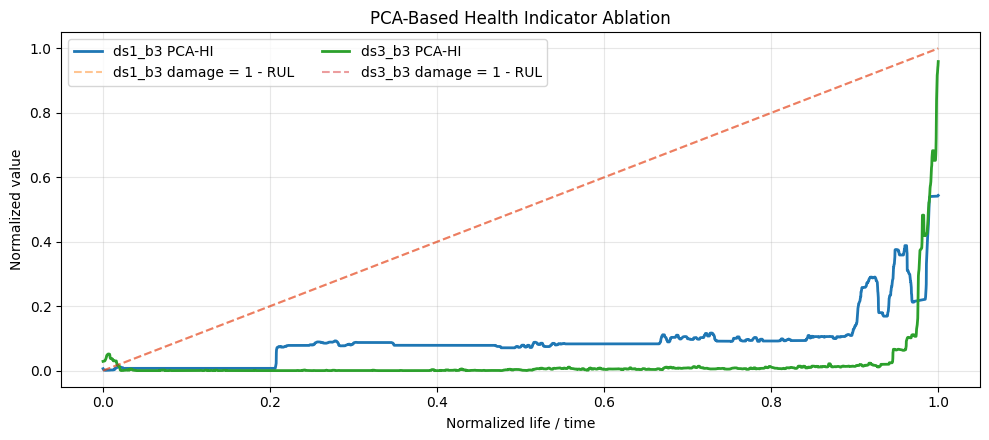

Saved PCA-HI plot to: /content/drive/MyDrive/IMS/figures/pca_hi_ablation.png


In [9]:
PCA_HI_FEATURES = MODEL_COLS.copy()
PCA_TEST_RUNS = sorted({run for spec in EXPERIMENTS for run in spec['test_runs']})

pca_hi_df = proc_df.sort_values(['run_id', 'elapsed_scaled']).reset_index(drop=True).copy()
hi_feature_matrix = (
    pca_hi_df[PCA_HI_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .values
)

hi_scaled = StandardScaler().fit_transform(hi_feature_matrix)
hi_raw = PCA(n_components=1).fit_transform(hi_scaled).ravel()
hi_min, hi_max = hi_raw.min(), hi_raw.max()
pca_hi = (hi_raw - hi_min) / (hi_max - hi_min + 1e-12)

pca_hi_df['damage_norm'] = 1.0 - pca_hi_df['rul_norm']
if pd.Series(pca_hi).corr(pca_hi_df['damage_norm'], method='spearman') < 0:
    pca_hi = 1.0 - pca_hi

pca_hi_df['pca_hi'] = pca_hi
pca_hi_df['pca_hi_smooth'] = (
    pca_hi_df
    .groupby('run_id')['pca_hi']
    .transform(lambda s: s.rolling(window=21, min_periods=1, center=True).median())
)
pca_hi_df['life_norm_for_plot'] = (
    pca_hi_df
    .groupby('run_id')['elapsed_scaled']
    .transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12))
)


def monotonic_increase_score(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return np.nan
    return float(np.mean(np.diff(values) >= -1e-8))


pca_hi_summary_rows = []
for run_id in PCA_TEST_RUNS:
    run = pca_hi_df[pca_hi_df['run_id'] == run_id].sort_values('life_norm_for_plot')
    pca_hi_summary_rows.append({
        'Run': run_id,
        'Monotonic increase score': monotonic_increase_score(run['pca_hi_smooth']),
        'Spearman corr(PCA-HI, damage)': float(run['pca_hi'].corr(run['damage_norm'], method='spearman')),
        'Spearman corr(PCA-HI, RUL)': float(run['pca_hi'].corr(run['rul_norm'], method='spearman')),
    })

pca_hi_summary = pd.DataFrame(pca_hi_summary_rows)
display(pca_hi_summary)

plt.figure(figsize=(10, 4.5))
for run_id in PCA_TEST_RUNS:
    run = pca_hi_df[pca_hi_df['run_id'] == run_id].sort_values('life_norm_for_plot')
    plt.plot(run['life_norm_for_plot'], run['pca_hi_smooth'], linewidth=2, label=f'{run_id} PCA-HI')
    plt.plot(run['life_norm_for_plot'], run['damage_norm'], linestyle='--', alpha=0.45, label=f'{run_id} damage = 1 - RUL')

plt.xlabel('Normalized life / time')
plt.ylabel('Normalized value')
plt.title('PCA-Based Health Indicator Ablation')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
pca_plot_path = FIGURE_DIR / 'pca_hi_ablation.png'
plt.savefig(pca_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved PCA-HI plot to:', pca_plot_path)


## Experiment Preparation Utilities

The same train/validation/test splits and scaled input features are reused across the data-only baseline, proposed DeepXDE model, LSTM baseline, and CNN baseline.

In [10]:
def make_balanced_train_df(df, run_ids):
    run_lengths = [len(df[df['run_id'] == run_id]) for run_id in run_ids]
    n_per_run = min(run_lengths)
    pieces = []
    for run_id in run_ids:
        run_df = df[df['run_id'] == run_id].sort_values('elapsed_scaled').copy()
        sample_idx = np.linspace(0, len(run_df) - 1, n_per_run).round().astype(int)
        pieces.append(run_df.iloc[sample_idx])
    return pd.concat(pieces, ignore_index=True)


def select_runs(df, run_ids):
    return (
        df[df['run_id'].isin(run_ids)]
        .sort_values(['run_id', 'elapsed_scaled', 'snapshot_index'])
        .copy()
    )


def prepare_experiment_context(spec):
    if spec.get('balanced_train', False):
        train_df = make_balanced_train_df(proc_df, spec['train_runs'])
    else:
        train_df = select_runs(proc_df, spec['train_runs'])

    val_df = select_runs(proc_df, spec['validation_runs'])
    test_df = select_runs(proc_df, spec['test_runs'])

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_df[FEATURE_COLS_MULTI]).astype('float32')
    X_val = scaler.transform(val_df[FEATURE_COLS_MULTI]).astype('float32')
    X_test = scaler.transform(test_df[FEATURE_COLS_MULTI]).astype('float32')

    X_train[:, 1:] = np.clip(X_train[:, 1:], 0, 1)
    X_val[:, 1:] = np.clip(X_val[:, 1:], 0, 1)
    X_test[:, 1:] = np.clip(X_test[:, 1:], 0, 1)

    y_train = train_df[[TARGET_COL]].values.astype('float32')
    y_val = val_df[[TARGET_COL]].values.astype('float32')
    y_test = test_df[[TARGET_COL]].values.astype('float32')

    return {
        'spec': spec,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'scaler': scaler,
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }


experiment_contexts = {spec['name']: prepare_experiment_context(spec) for spec in EXPERIMENTS}

for name, ctx in experiment_contexts.items():
    print(name)
    print('  train:', ctx['X_train'].shape, 'val:', ctx['X_val'].shape, 'test:', ctx['X_test'].shape)
    print('  train runs:', ctx['train_df']['run_id'].value_counts().to_dict())


Exp 1
  train: (3140, 13) val: (2156, 13) test: (6324, 13)
  train runs: {'ds1_b3': 2156, 'ds2_b1': 984}
Exp 2
  train: (3140, 13) val: (2156, 13) test: (6324, 13)
  train runs: {'ds1_b4': 2156, 'ds2_b1': 984}
Exp 3
  train: (1968, 13) val: (2156, 13) test: (2156, 13)
  train runs: {'ds2_b1': 984, 'ds3_b3': 984}


## Data-Only Neural Baseline and Proposed DeepXDE Model

The data-only baseline is a neural network trained only on RUL labels. The proposed model uses the same input features and normalized RUL target, with a weak physics-informed loss that encourages monotonic RUL and uses fault-frequency energy as a soft degradation prior.

In [11]:
BASELINE_ITERATIONS = 15000
PINN_ITERATIONS = 20000

PINN_MONOTONIC_WEIGHT = 0.005
PINN_SPECTRAL_PRIOR_WEIGHT = 0.001
PINN_MONOTONIC_TOLERANCE = 0.01
PINN_SPECTRAL_PRIOR_STRENGTH = 0.15
PINN_SPECTRAL_PRIOR_MARGIN = 0.05


def predict_dde_model(model, X):
    pred = model.predict(X)
    return np.clip(pred, 0, 1).ravel()


def train_data_only_baseline(ctx):
    data = dde.data.DataSet(
        X_train=ctx['X_train'],
        y_train=ctx['y_train'],
        X_test=ctx['X_val'],
        y_test=ctx['y_val'],
    )
    net = dde.nn.FNN([ctx['X_train'].shape[1], 64, 64, 64, 1], 'tanh', 'Glorot uniform')
    net.apply_output_transform(lambda x, y: torch.sigmoid(y))

    model = dde.Model(data, net)
    model.compile('adam', lr=5e-4, loss='MSE')
    model.train(iterations=BASELINE_ITERATIONS, display_every=1000)
    return model


def weak_fault_frequency_physics_residual(x, y):
    dR_dt = dde.grad.jacobian(y, x, i=0, j=TIME_COL)
    Ekin = x[:, EKIN_COL:EKIN_COL+1]
    damage = 1.0 - y

    monotonicity_residual = torch.relu(dR_dt - PINN_MONOTONIC_TOLERANCE)

    spectral_damage_floor = PINN_SPECTRAL_PRIOR_STRENGTH * Ekin
    spectral_prior_residual = torch.relu(spectral_damage_floor - damage - PINN_SPECTRAL_PRIOR_MARGIN)

    return [monotonicity_residual, spectral_prior_residual]


def train_proposed_deepxde_model(ctx):
    geom = dde.geometry.PointCloud(ctx['X_train'])
    observe_rul = dde.icbc.PointSetBC(ctx['X_train'], ctx['y_train'], component=0)

    data = dde.data.PDE(
        geom,
        weak_fault_frequency_physics_residual,
        [observe_rul],
        num_domain=len(ctx['X_train']),
        num_boundary=0,
        anchors=ctx['X_train'],
        num_test=None,
    )

    net = dde.nn.FNN([ctx['X_train'].shape[1], 64, 64, 64, 1], 'tanh', 'Glorot uniform')
    net.apply_output_transform(lambda x, y: torch.sigmoid(y))

    model = dde.Model(data, net)
    model.compile(
        'adam',
        lr=5e-4,
        loss_weights=[PINN_MONOTONIC_WEIGHT, PINN_SPECTRAL_PRIOR_WEIGHT, 1.00],
    )
    model.train(iterations=PINN_ITERATIONS, display_every=1000)
    return model


core_results_rows = []
prediction_store = {}
trained_models = {}

for spec in EXPERIMENTS:
    ctx = experiment_contexts[spec['name']]
    full_x = np.linspace(0, 1, len(ctx['y_test'].reshape(-1)))
    prediction_store[spec['name']] = {
        'true': ctx['y_test'].reshape(-1),
        'x_true': full_x,
        'x_by_model': {},
    }
    trained_models[spec['name']] = {}

    print(f"\n=== {spec['name']} data-only baseline ===")
    baseline_model = train_data_only_baseline(ctx)
    baseline_pred = predict_dde_model(baseline_model, ctx['X_test'])
    baseline_metrics = regression_metrics(ctx['y_test'], baseline_pred)
    print_metrics(f"{spec['name']} {DATA_BASELINE_NAME}", baseline_metrics)
    core_results_rows.append(evaluation_row(spec, DATA_BASELINE_NAME, ctx['y_test'], baseline_pred))
    prediction_store[spec['name']][DATA_BASELINE_NAME] = baseline_pred
    prediction_store[spec['name']]['x_by_model'][DATA_BASELINE_NAME] = full_x
    trained_models[spec['name']][DATA_BASELINE_NAME] = baseline_model

    print(f"\n=== {spec['name']} proposed DeepXDE model ===")
    proposed_model = train_proposed_deepxde_model(ctx)
    proposed_pred = predict_dde_model(proposed_model, ctx['X_test'])
    proposed_metrics = regression_metrics(ctx['y_test'], proposed_pred)
    print_metrics(f"{spec['name']} {PROPOSED_MODEL_NAME}", proposed_metrics)
    core_results_rows.append(evaluation_row(spec, PROPOSED_MODEL_NAME, ctx['y_test'], proposed_pred))
    prediction_store[spec['name']][PROPOSED_MODEL_NAME] = proposed_pred
    prediction_store[spec['name']]['x_by_model'][PROPOSED_MODEL_NAME] = full_x
    trained_models[spec['name']][PROPOSED_MODEL_NAME] = proposed_model

core_results = pd.DataFrame(core_results_rows)
display(core_results)



=== Exp 1 data-only baseline ===
Compiling model...
'compile' took 12.771445 s

Training model...

Step      Train loss    Test loss     Test metric
0         [8.55e-02]    [9.59e-02]    []  
1000      [6.40e-03]    [1.03e-02]    []  
2000      [5.44e-04]    [1.11e-02]    []  
3000      [1.96e-04]    [1.66e-02]    []  
4000      [1.71e-04]    [8.08e-03]    []  
5000      [7.31e-05]    [3.70e-03]    []  
6000      [5.49e-05]    [2.56e-03]    []  
7000      [4.43e-05]    [2.16e-03]    []  
8000      [5.45e-05]    [2.06e-03]    []  
9000      [1.02e-04]    [2.04e-03]    []  
10000     [2.94e-05]    [1.62e-03]    []  
11000     [6.35e-05]    [1.40e-03]    []  
12000     [2.50e-05]    [1.47e-03]    []  
13000     [2.32e-05]    [1.44e-03]    []  
14000     [2.18e-05]    [1.42e-03]    []  
15000     [2.02e-05]    [1.42e-03]    []  

Best model at step 15000:
  train loss: 2.02e-05
  test loss: 1.42e-03
  test metric: []

'train' took 41.504301 s

Exp 1 Data-only neural baseline
MAE  = 0.1431

,Experiment,Train runs,Validation run,Test run,Model,MAE,RMSE,R²
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Data-only neural baseline,0.143122,0.171692,0.645533
1,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Proposed DeepXDE Physics-Informed RUL Model,0.063869,0.119313,0.828822
2,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Data-only neural baseline,0.095136,0.136554,0.775776
3,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Proposed DeepXDE Physics-Informed RUL Model,0.135191,0.165566,0.670380
4,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Data-only neural baseline,0.211294,0.287538,-0.024471
5,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Proposed DeepXDE Physics-Informed RUL Model,0.208360,0.287452,-0.023858


## Sequence Baseline Utilities

The LSTM and CNN baselines use sliding windows from the same scaled feature table and predict normalized RUL.

In [12]:
SEQUENCE_LENGTH = 20
SEQUENCE_EPOCHS = 60
SEQUENCE_PATIENCE = 8
SEQUENCE_BATCH_SIZE = 128


def make_sequence_arrays(df, scaler, run_ids, sequence_length=SEQUENCE_LENGTH):
    X_seq, y_seq, x_seq = [], [], []
    for run_id in run_ids:
        run = df[df['run_id'] == run_id].sort_values(['elapsed_scaled', 'snapshot_index']).copy()
        if len(run) <= sequence_length:
            continue

        X_run = scaler.transform(run[FEATURE_COLS_MULTI]).astype('float32')
        X_run[:, 1:] = np.clip(X_run[:, 1:], 0, 1)
        y_run = run[[TARGET_COL]].values.astype('float32')
        x_run = np.linspace(0, 1, len(run), dtype=np.float32)

        for i in range(sequence_length, len(run)):
            X_seq.append(X_run[i - sequence_length:i])
            y_seq.append(y_run[i])
            x_seq.append(x_run[i])

    if not X_seq:
        raise ValueError('Not enough samples to build sequence arrays.')
    return (
        np.stack(X_seq).astype('float32'),
        np.vstack(y_seq).astype('float32'),
        np.asarray(x_seq, dtype='float32'),
    )


def predict_torch_sequence_model(model, X, device):
    model.eval()
    preds = []
    X_tensor = torch.from_numpy(X)
    with torch.no_grad():
        for start in range(0, len(X_tensor), SEQUENCE_BATCH_SIZE):
            batch_X = X_tensor[start:start + SEQUENCE_BATCH_SIZE].to(device)
            preds.append(model(batch_X).cpu().numpy())
    return np.clip(np.vstack(preds).reshape(-1), 0, 1)


def train_torch_sequence_model(model_class, ctx, spec, model_name, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train_seq, y_train_seq, _ = make_sequence_arrays(ctx['train_df'], ctx['scaler'], spec['train_runs'])
    X_val_seq, y_val_seq, _ = make_sequence_arrays(ctx['val_df'], ctx['scaler'], spec['validation_runs'])
    X_test_seq, y_test_seq, x_test_seq = make_sequence_arrays(ctx['test_df'], ctx['scaler'], spec['test_runs'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model_class(input_dim=X_train_seq.shape[-1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.MSELoss()

    X_train_tensor = torch.from_numpy(X_train_seq)
    y_train_tensor = torch.from_numpy(y_train_seq)
    n_train = len(X_train_tensor)

    best_loss = np.inf
    best_state = None
    patience_left = SEQUENCE_PATIENCE

    for epoch in range(1, SEQUENCE_EPOCHS + 1):
        model.train()
        epoch_losses = []
        permutation = np.random.permutation(n_train)

        for start in range(0, n_train, SEQUENCE_BATCH_SIZE):
            batch_idx = permutation[start:start + SEQUENCE_BATCH_SIZE]
            batch_X = X_train_tensor[batch_idx].to(device)
            batch_y = y_train_tensor[batch_idx].to(device)

            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        val_pred = predict_torch_sequence_model(model, X_val_seq, device)
        monitor_loss = mean_squared_error(y_val_seq.reshape(-1), val_pred.reshape(-1))

        if monitor_loss < best_loss - 1e-6:
            best_loss = monitor_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = SEQUENCE_PATIENCE
        else:
            patience_left -= 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'{spec["name"]} {model_name} epoch {epoch:03d} monitor MSE = {monitor_loss:.6f}')

        if patience_left <= 0:
            print(f'{spec["name"]} {model_name} early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_pred = predict_torch_sequence_model(model, X_test_seq, device)
    print_metrics(f'{spec["name"]} {model_name}', regression_metrics(y_test_seq, test_pred))
    return model, y_test_seq.reshape(-1), test_pred, x_test_seq

## LSTM Baseline

In [13]:
class LSTMRULRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


lstm_results_rows = []
for spec in EXPERIMENTS:
    ctx = experiment_contexts[spec['name']]
    model, y_seq, pred_seq, x_seq = train_torch_sequence_model(
        LSTMRULRegressor,
        ctx,
        spec,
        LSTM_BASELINE_NAME,
        seed=42,
    )
    lstm_results_rows.append(evaluation_row(spec, LSTM_BASELINE_NAME, y_seq, pred_seq))
    prediction_store[spec['name']][LSTM_BASELINE_NAME] = pred_seq
    prediction_store[spec['name']]['x_by_model'][LSTM_BASELINE_NAME] = x_seq
    trained_models[spec['name']][LSTM_BASELINE_NAME] = model

lstm_results = pd.DataFrame(lstm_results_rows)
display(lstm_results)


Exp 1 LSTM baseline epoch 001 monitor MSE = 0.061542
Exp 1 LSTM baseline epoch 010 monitor MSE = 0.006822
Exp 1 LSTM baseline early stopping at epoch 18
Exp 1 LSTM baseline
MAE  = 0.075071
RMSE = 0.093678
R²   = 0.893808

Exp 2 LSTM baseline epoch 001 monitor MSE = 0.059492
Exp 2 LSTM baseline epoch 010 monitor MSE = 0.022724
Exp 2 LSTM baseline early stopping at epoch 11
Exp 2 LSTM baseline
MAE  = 0.134687
RMSE = 0.145443
R²   = 0.744021

Exp 3 LSTM baseline epoch 001 monitor MSE = 0.081415
Exp 3 LSTM baseline epoch 010 monitor MSE = 0.066376
Exp 3 LSTM baseline early stopping at epoch 10
Exp 3 LSTM baseline
MAE  = 0.185205
RMSE = 0.225019
R²   = 0.349877



,Experiment,Train runs,Validation run,Test run,Model,MAE,RMSE,R²
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,LSTM baseline,0.075071,0.093678,0.893808
1,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,LSTM baseline,0.134687,0.145443,0.744021
2,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,LSTM baseline,0.185205,0.225019,0.349877


## CNN Baseline

The CNN comparison is required and is included in the final result table and final prediction plots.

In [14]:
class CNNRULRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.head(self.encoder(x))


cnn_results_rows = []
for spec in EXPERIMENTS:
    ctx = experiment_contexts[spec['name']]
    model, y_seq, pred_seq, x_seq = train_torch_sequence_model(
        CNNRULRegressor,
        ctx,
        spec,
        CNN_BASELINE_NAME,
        seed=123,
    )
    cnn_results_rows.append(evaluation_row(spec, CNN_BASELINE_NAME, y_seq, pred_seq))
    prediction_store[spec['name']][CNN_BASELINE_NAME] = pred_seq
    prediction_store[spec['name']]['x_by_model'][CNN_BASELINE_NAME] = x_seq
    trained_models[spec['name']][CNN_BASELINE_NAME] = model

cnn_results = pd.DataFrame(cnn_results_rows)
display(cnn_results)


Exp 1 CNN baseline epoch 001 monitor MSE = 0.033336
Exp 1 CNN baseline epoch 010 monitor MSE = 0.004545
Exp 1 CNN baseline early stopping at epoch 14
Exp 1 CNN baseline
MAE  = 0.219489
RMSE = 0.243998
R²   = 0.279567

Exp 2 CNN baseline epoch 001 monitor MSE = 0.045341
Exp 2 CNN baseline epoch 010 monitor MSE = 0.017084
Exp 2 CNN baseline epoch 020 monitor MSE = 0.012724
Exp 2 CNN baseline epoch 030 monitor MSE = 0.012868
Exp 2 CNN baseline early stopping at epoch 37
Exp 2 CNN baseline
MAE  = 0.214990
RMSE = 0.251835
R²   = 0.232545

Exp 3 CNN baseline epoch 001 monitor MSE = 0.054608
Exp 3 CNN baseline epoch 010 monitor MSE = 0.144413
Exp 3 CNN baseline early stopping at epoch 12
Exp 3 CNN baseline
MAE  = 0.157018
RMSE = 0.203160
R²   = 0.470049



,Experiment,Train runs,Validation run,Test run,Model,MAE,RMSE,R²
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,CNN baseline,0.219489,0.243998,0.279567
1,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,CNN baseline,0.214990,0.251835,0.232545
2,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,CNN baseline,0.157018,0.203160,0.470049


## Final Comparison and Prediction Plots

The final table includes all required models. One final plot per experiment compares true normalized RUL with predictions from the data-only neural baseline, proposed DeepXDE model, LSTM baseline, and CNN baseline. Sequence models are plotted at their aligned post-window test-life positions so the sequence-length offset is handled correctly.

,Experiment,Train runs,Validation run,Test run,Model,MAE,RMSE,R²
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Data-only neural baseline,0.143122,0.171692,0.645533
1,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Proposed DeepXDE Physics-Informed RUL Model,0.063869,0.119313,0.828822
2,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,LSTM baseline,0.075071,0.093678,0.893808
3,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,CNN baseline,0.219489,0.243998,0.279567
4,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Data-only neural baseline,0.095136,0.136554,0.775776
5,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Proposed DeepXDE Physics-Informed RUL Model,0.135191,0.165566,0.670380
6,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,LSTM baseline,0.134687,0.145443,0.744021
7,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,CNN baseline,0.214990,0.251835,0.232545
8,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Data-only neural baseline,0.211294,0.287538,-0.024471
9,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Proposed DeepXDE Physics-Informed RUL Model,0.208360,0.287452,-0.023858


Saved final results to: /content/drive/MyDrive/IMS/final_results_table.csv
Saved PCA-HI ablation summary to: /content/drive/MyDrive/IMS/pca_hi_ablation_summary.csv


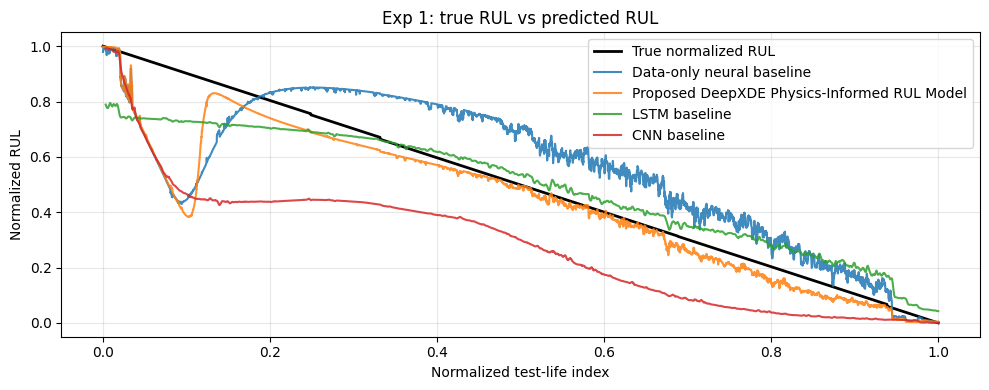

Saved plot to: /content/drive/MyDrive/IMS/figures/exp_1_true_vs_predicted_rul.png


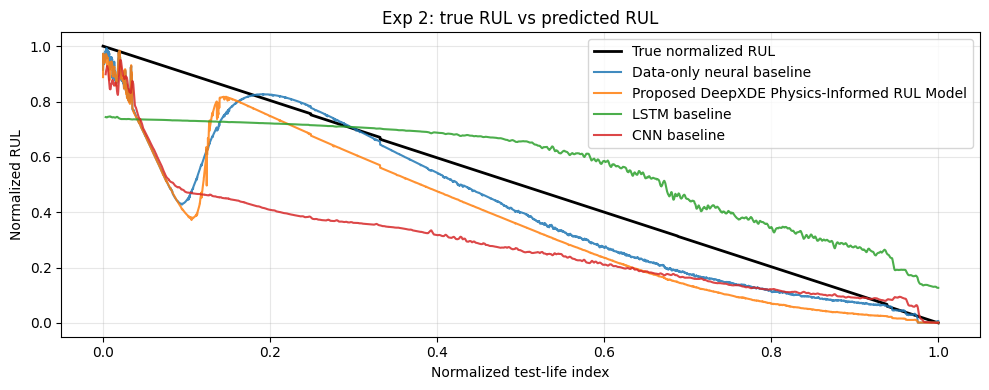

Saved plot to: /content/drive/MyDrive/IMS/figures/exp_2_true_vs_predicted_rul.png


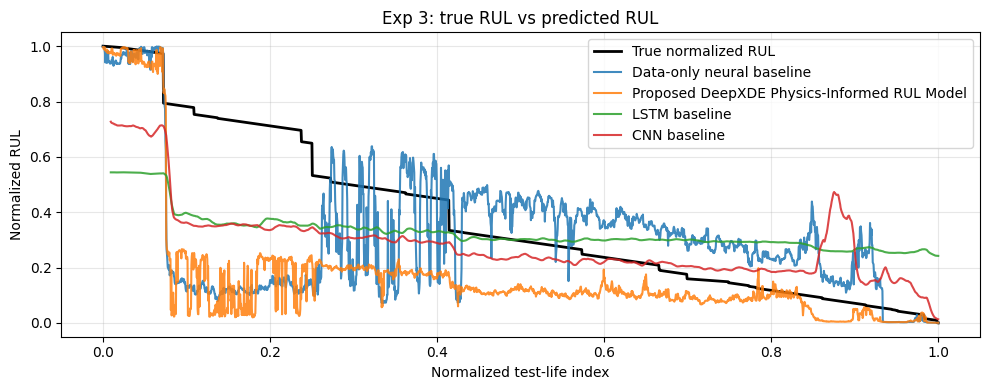

Saved plot to: /content/drive/MyDrive/IMS/figures/exp_3_true_vs_predicted_rul.png


In [15]:
final_results = pd.concat([core_results, lstm_results, cnn_results], ignore_index=True)
final_results['Model'] = pd.Categorical(final_results['Model'], categories=MODEL_ORDER, ordered=True)
final_results = final_results.sort_values(['Experiment', 'Model']).reset_index(drop=True)
final_results['Model'] = final_results['Model'].astype(str)
final_results = final_results[
    ['Experiment', 'Train runs', 'Validation run', 'Test run', 'Model', 'MAE', 'RMSE', 'R²']
]
display(final_results)

final_results_path = DATA_DIR / 'final_results_table.csv'
pca_hi_summary_path = DATA_DIR / 'pca_hi_ablation_summary.csv'
final_results.to_csv(final_results_path, index=False)
pca_hi_summary.to_csv(pca_hi_summary_path, index=False)
print('Saved final results to:', final_results_path)
print('Saved PCA-HI ablation summary to:', pca_hi_summary_path)


def plot_final_predictions(spec):
    exp_name = spec['name']
    preds = prediction_store[exp_name]
    true_rul = preds['true']
    x_true = preds['x_true']

    plt.figure(figsize=(10, 4))
    plt.plot(x_true, true_rul, label='True normalized RUL', linewidth=2, color='black')

    for model_name in MODEL_ORDER:
        if model_name not in preds:
            continue
        pred = preds[model_name]
        x_pred = preds['x_by_model'][model_name]
        if len(x_pred) != len(pred):
            raise ValueError(f'Misaligned x/pred lengths for {exp_name} {model_name}: {len(x_pred)} vs {len(pred)}')
        plt.plot(x_pred, pred, label=model_name, alpha=0.85)

    plt.xlabel('Normalized test-life index')
    plt.ylabel('Normalized RUL')
    plt.title(f'{exp_name}: true RUL vs predicted RUL')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    figure_path = FIGURE_DIR / f'{exp_name.lower().replace(" ", "_")}_true_vs_predicted_rul.png'
    plt.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved plot to:', figure_path)


for spec in EXPERIMENTS:
    plot_final_predictions(spec)

## Additional Thesis Tables and Figures

The following sections add explanatory thesis outputs generated from the already executed pipeline variables. They do not retrain, redesign, or replace the final research methodology.

### Dataset Summary Table

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/dataset_summary_table.csv


,Run ID,IMS dataset,Bearing number,Failure type if available,Number of samples,Used in experiments,Notes
0,ds2_b1,2nd_test,1,Not specified in cleaned notebook,984,Exp 1 Train; Exp 2 Train; Exp 3 Train,Run-to-failure IMS bearing run used in cross-b...
1,ds1_b3,1st_test,3,Not specified in cleaned notebook,2156,Exp 1 Train; Exp 2 Validation; Exp 3 Test,Run-to-failure IMS bearing run used in cross-b...
2,ds1_b4,1st_test,4,Not specified in cleaned notebook,2156,Exp 1 Validation; Exp 2 Train; Exp 3 Validation,Run-to-failure IMS bearing run used in cross-b...
3,ds3_b3,3rd_test,3,Not specified in cleaned notebook,6324,Exp 1 Test; Exp 2 Test; Exp 3 Train,Run-to-failure IMS bearing run used in cross-b...


Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_dataset_sample_counts.png


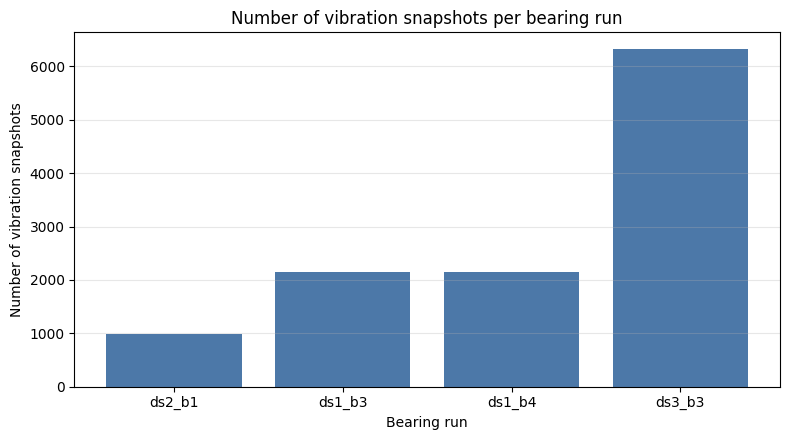

In [16]:
run_metadata = {
    run_id: {'IMS dataset': dataset, 'Bearing number': bearing}
    for run_id, dataset, bearing in TARGET_RUNS
}

usage_by_run = {run_id: [] for run_id in run_metadata}
for spec in EXPERIMENTS:
    for role_key, role_label in [
        ('train_runs', 'Train'),
        ('validation_runs', 'Validation'),
        ('test_runs', 'Test'),
    ]:
        for run_id in spec[role_key]:
            usage_by_run.setdefault(run_id, []).append(f"{spec['name']} {role_label}")

summary_rows = []
for run_id in [run_id for run_id, _, _ in TARGET_RUNS]:
    run_df = multi_df[multi_df['run_id'] == run_id]
    summary_rows.append({
        'Run ID': run_id,
        'IMS dataset': run_metadata[run_id]['IMS dataset'],
        'Bearing number': run_metadata[run_id]['Bearing number'],
        'Failure type if available': 'Not specified in cleaned notebook',
        'Number of samples': int(len(run_df)),
        'Used in experiments': '; '.join(usage_by_run.get(run_id, [])),
        'Notes': 'Run-to-failure IMS bearing run used in cross-bearing experiments',
    })

dataset_summary_table = pd.DataFrame(summary_rows)
save_table(dataset_summary_table, 'dataset_summary_table.csv')

plt.figure(figsize=(8, 4.5))
plt.bar(dataset_summary_table['Run ID'], dataset_summary_table['Number of samples'], color='#4c78a8')
plt.title('Number of vibration snapshots per bearing run')
plt.xlabel('Bearing run')
plt.ylabel('Number of vibration snapshots')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_current_figure('fig_dataset_sample_counts.png')
plt.show()

### Feature Description Table

In [17]:
feature_rows = [
    {'Feature name': 'elapsed_scaled', 'Domain': 'time feature', 'Physical meaning': 'Normalized elapsed operating time used as temporal input', 'Used by models': 'yes'},
    {'Feature name': 'rms', 'Domain': 'time-domain', 'Physical meaning': 'Signal energy amplitude through root mean square vibration', 'Used by models': 'yes'},
    {'Feature name': 'std', 'Domain': 'time-domain', 'Physical meaning': 'Vibration dispersion around the mean', 'Used by models': 'yes'},
    {'Feature name': 'ptp', 'Domain': 'time-domain', 'Physical meaning': 'Peak-to-peak vibration range', 'Used by models': 'yes'},
    {'Feature name': 'kurtosis', 'Domain': 'time-domain', 'Physical meaning': 'Impulsiveness of vibration signal', 'Used by models': 'yes'},
    {'Feature name': 'crest_factor', 'Domain': 'time-domain', 'Physical meaning': 'Peak amplitude relative to RMS', 'Used by models': 'yes'},
    {'Feature name': 'mean_abs', 'Domain': 'time-domain', 'Physical meaning': 'Mean absolute vibration amplitude', 'Used by models': 'yes'},
    {'Feature name': 'E_FTF', 'Domain': 'physics-informed frequency feature', 'Physical meaning': 'Envelope spectral energy around cage fault train frequency harmonics', 'Used by models': 'yes'},
    {'Feature name': 'E_BPFO', 'Domain': 'physics-informed frequency feature', 'Physical meaning': 'Envelope spectral energy around outer-race fault frequency harmonics', 'Used by models': 'yes'},
    {'Feature name': 'E_BPFI', 'Domain': 'physics-informed frequency feature', 'Physical meaning': 'Envelope spectral energy around inner-race fault frequency harmonics', 'Used by models': 'yes'},
    {'Feature name': 'E_BSF', 'Domain': 'physics-informed frequency feature', 'Physical meaning': 'Envelope spectral energy around rolling-element fault frequency harmonics', 'Used by models': 'yes'},
    {'Feature name': 'E_kin', 'Domain': 'physics-informed frequency feature', 'Physical meaning': 'Combined bearing kinematic fault-frequency spectral energy', 'Used by models': 'yes'},
    {'Feature name': 'sigma_H_norm', 'Domain': 'auxiliary placeholder', 'Physical meaning': 'Constant placeholder in cleaned pipeline; not a Hertzian contact stress calculation', 'Used by models': 'yes'},
]
feature_description_table = pd.DataFrame(feature_rows)
feature_description_table = feature_description_table[feature_description_table['Feature name'].isin(FEATURE_COLS_MULTI)]
save_table(feature_description_table, 'feature_description_table.csv')

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/feature_description_table.csv


,Feature name,Domain,Physical meaning,Used by models
0,elapsed_scaled,time feature,Normalized elapsed operating time used as temp...,yes
1,rms,time-domain,Signal energy amplitude through root mean squa...,yes
2,std,time-domain,Vibration dispersion around the mean,yes
3,ptp,time-domain,Peak-to-peak vibration range,yes
4,kurtosis,time-domain,Impulsiveness of vibration signal,yes
5,crest_factor,time-domain,Peak amplitude relative to RMS,yes
6,mean_abs,time-domain,Mean absolute vibration amplitude,yes
7,E_FTF,physics-informed frequency feature,Envelope spectral energy around cage fault tra...,yes
8,E_BPFO,physics-informed frequency feature,Envelope spectral energy around outer-race fau...,yes
9,E_BPFI,physics-informed frequency feature,Envelope spectral energy around inner-race fau...,yes


PosixPath('/content/drive/MyDrive/thesis_outputs/figures_tables/feature_description_table.csv')

### Bearing Fault Frequency Table

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/fault_frequency_table.csv


,Frequency name,Symbol,Value in Hz,Related bearing component,Extracted feature
0,FTF,FTF,14.775217,Cage / fundamental train,E_FTF
1,BPFO,BPFO,236.403471,Outer race,E_BPFO
2,BPFI,BPFI,296.929862,Inner race,E_BPFI
3,BSF,BSF,139.916656,Rolling element,E_BSF


Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_fault_frequencies.png


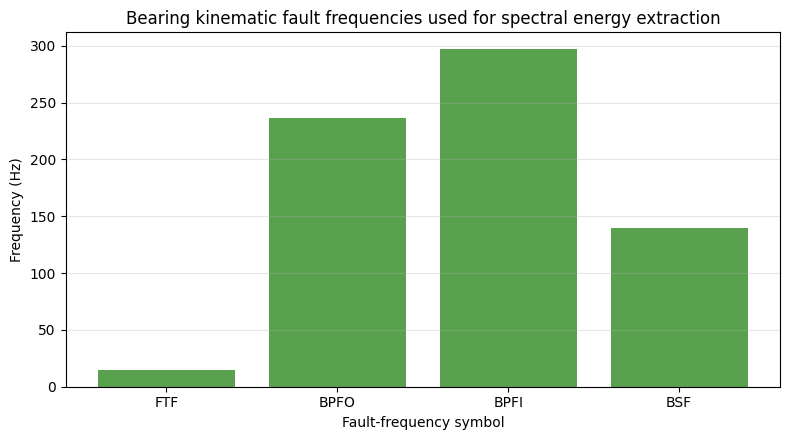

In [18]:
fault_component_map = {
    'FTF': ('FTF', 'Cage / fundamental train'),
    'BPFO': ('BPFO', 'Outer race'),
    'BPFI': ('BPFI', 'Inner race'),
    'BSF': ('BSF', 'Rolling element'),
}

fault_frequency_table = pd.DataFrame([
    {
        'Frequency name': name,
        'Symbol': symbol,
        'Value in Hz': float(FAULT_FREQS[name]),
        'Related bearing component': component,
        'Extracted feature': f'E_{name}',
    }
    for name, (symbol, component) in fault_component_map.items()
])
save_table(fault_frequency_table, 'fault_frequency_table.csv')

plt.figure(figsize=(8, 4.5))
plt.bar(fault_frequency_table['Symbol'], fault_frequency_table['Value in Hz'], color='#59a14f')
plt.title('Bearing kinematic fault frequencies used for spectral energy extraction')
plt.xlabel('Fault-frequency symbol')
plt.ylabel('Frequency (Hz)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_current_figure('fig_fault_frequencies.png')
plt.show()

### Experiment Split Table

In [19]:
experiment_purpose = {
    'Exp 1': 'Cross-dataset/cross-bearing transfer with ds3_b3 held out for testing',
    'Exp 2': 'Alternative training-bearing combination with the same ds3_b3 test run',
    'Exp 3': 'Cross-dataset transfer to ds1_b3 with balanced training runs',
}
experiment_split_table = pd.DataFrame([
    {
        'Experiment': spec['name'],
        'Train runs': run_label(spec['train_runs']),
        'Validation run': run_label(spec['validation_runs']),
        'Test run': run_label(spec['test_runs']),
        'Purpose': experiment_purpose.get(spec['name'], 'Cross-bearing RUL generalization experiment'),
    }
    for spec in EXPERIMENTS
])
save_table(experiment_split_table, 'experiment_split_table.csv')

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/experiment_split_table.csv


,Experiment,Train runs,Validation run,Test run,Purpose
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Cross-dataset/cross-bearing transfer with ds3_...
1,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Alternative training-bearing combination with ...
2,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Cross-dataset transfer to ds1_b3 with balanced...


PosixPath('/content/drive/MyDrive/thesis_outputs/figures_tables/experiment_split_table.csv')

### Model Summary Table

In [20]:
model_summary_table = pd.DataFrame([
    {
        'Model': DATA_BASELINE_NAME,
        'Model type': 'Feed-forward neural network',
        'Input format': 'Single snapshot feature vector',
        'Target': 'Normalized RUL',
        'Role in thesis': 'Data-only baseline',
        'Main purpose': 'Measure predictive performance without physics-informed residual losses',
    },
    {
        'Model': PROPOSED_MODEL_NAME,
        'Model type': 'DeepXDE physics-informed neural network',
        'Input format': 'Single snapshot feature vector with time and fault-frequency energy features',
        'Target': 'Normalized RUL',
        'Role in thesis': 'Proposed model',
        'Main purpose': 'Combine RUL supervision with monotonic degradation and fault-frequency spectral consistency priors',
    },
    {
        'Model': LSTM_BASELINE_NAME,
        'Model type': 'Recurrent neural network',
        'Input format': 'Sliding-window sequence of feature vectors',
        'Target': 'Normalized RUL',
        'Role in thesis': 'Sequence baseline',
        'Main purpose': 'Compare against a temporal data-driven model',
    },
    {
        'Model': CNN_BASELINE_NAME,
        'Model type': '1D convolutional neural network',
        'Input format': 'Sliding-window sequence of feature vectors',
        'Target': 'Normalized RUL',
        'Role in thesis': 'Sequence baseline',
        'Main purpose': 'Compare against a local temporal-pattern data-driven model',
    },
])
save_table(model_summary_table, 'model_summary_table.csv')

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/model_summary_table.csv


,Model,Model type,Input format,Target,Role in thesis,Main purpose
0,Data-only neural baseline,Feed-forward neural network,Single snapshot feature vector,Normalized RUL,Data-only baseline,Measure predictive performance without physics...
1,Proposed DeepXDE Physics-Informed RUL Model,DeepXDE physics-informed neural network,Single snapshot feature vector with time and f...,Normalized RUL,Proposed model,Combine RUL supervision with monotonic degrada...
2,LSTM baseline,Recurrent neural network,Sliding-window sequence of feature vectors,Normalized RUL,Sequence baseline,Compare against a temporal data-driven model
3,CNN baseline,1D convolutional neural network,Sliding-window sequence of feature vectors,Normalized RUL,Sequence baseline,Compare against a local temporal-pattern data-...


PosixPath('/content/drive/MyDrive/thesis_outputs/figures_tables/model_summary_table.csv')

### Loss Function Component Table

In [21]:
loss_component_table = pd.DataFrame([
    {
        'Loss term': 'Data loss',
        'Used in which model': 'All neural models; supervised term in proposed DeepXDE model',
        'Purpose': 'Minimize error between predicted normalized RUL and true normalized RUL',
        'Thesis interpretation': 'Primary RUL prediction objective',
    },
    {
        'Loss term': 'Monotonicity/degradation loss',
        'Used in which model': PROPOSED_MODEL_NAME,
        'Purpose': 'Discourage physically implausible local increases in RUL',
        'Thesis interpretation': 'Encodes the assumption that remaining life should generally decrease as operation continues',
    },
    {
        'Loss term': 'Fault-frequency/spectral consistency loss',
        'Used in which model': PROPOSED_MODEL_NAME,
        'Purpose': 'Use bearing fault-frequency spectral energy as a weak degradation prior',
        'Thesis interpretation': 'Links kinematic bearing fault information to RUL degradation without forcing PCA-HI as the target',
    },
    {
        'Loss term': 'Total physics-informed loss',
        'Used in which model': PROPOSED_MODEL_NAME,
        'Purpose': 'Weighted sum of supervised RUL loss and weak physics-informed residual losses',
        'Thesis interpretation': 'Defines the proposed DeepXDE physics-informed RUL objective; no full Hertzian contact stress is claimed',
    },
])
save_table(loss_component_table, 'loss_component_table.csv')

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/loss_component_table.csv


,Loss term,Used in which model,Purpose,Thesis interpretation
0,Data loss,All neural models; supervised term in proposed...,Minimize error between predicted normalized RU...,Primary RUL prediction objective
1,Monotonicity/degradation loss,Proposed DeepXDE Physics-Informed RUL Model,Discourage physically implausible local increa...,Encodes the assumption that remaining life sho...
2,Fault-frequency/spectral consistency loss,Proposed DeepXDE Physics-Informed RUL Model,Use bearing fault-frequency spectral energy as...,Links kinematic bearing fault information to R...
3,Total physics-informed loss,Proposed DeepXDE Physics-Informed RUL Model,Weighted sum of supervised RUL loss and weak p...,Defines the proposed DeepXDE physics-informed ...


PosixPath('/content/drive/MyDrive/thesis_outputs/figures_tables/loss_component_table.csv')

### Raw Vibration Signal Plot: Healthy vs Near-Failure

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_raw_vibration_healthy_vs_failure.png


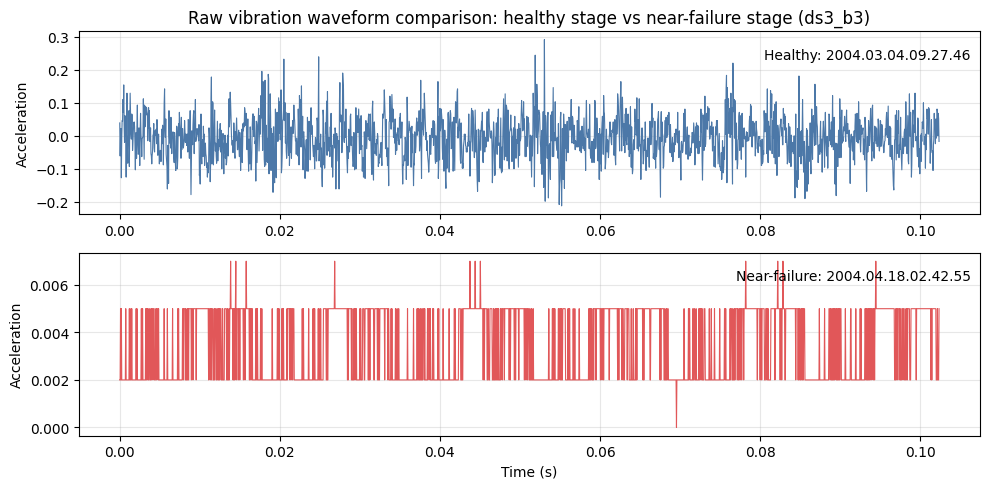

In [22]:
def get_raw_signal_for_run(run_id, position='early'):
    metadata = run_metadata[run_id]
    dataset = metadata['IMS dataset']
    bearing = metadata['Bearing number']
    files = list_snapshots(ZIP_PATHS[dataset])
    inner_file = files[0] if position == 'early' else files[-1]
    expected_cols = 8 if dataset == '1st_test' else 4
    arr = load_snapshot_from_zip(ZIP_PATHS[dataset], inner_file, expected_cols)

    selected_channels = []
    for ch in range(expected_cols):
        ch_bearing, _ = channel_to_bearing(dataset, ch)
        if ch_bearing == bearing:
            selected_channels.append(ch)

    if not selected_channels:
        raise ValueError(f'No channel found for {run_id}')

    signal = arr[:, selected_channels[0]]
    return signal, Path(inner_file).name

raw_plot_run = 'ds3_b3' if 'ds3_b3' in run_metadata else list(run_metadata.keys())[0]
try:
    healthy_signal, healthy_file = get_raw_signal_for_run(raw_plot_run, 'early')
    failure_signal, failure_file = get_raw_signal_for_run(raw_plot_run, 'late')
    n_plot = min(2048, len(healthy_signal), len(failure_signal))
    t = np.arange(n_plot) / FS

    plt.figure(figsize=(10, 5))
    plt.subplot(2, 1, 1)
    plt.plot(t, healthy_signal[:n_plot], linewidth=0.8, color='#4c78a8')
    plt.title(f'Raw vibration waveform comparison: healthy stage vs near-failure stage ({raw_plot_run})')
    plt.ylabel('Acceleration')
    plt.grid(True, alpha=0.3)
    plt.text(0.99, 0.85, f'Healthy: {healthy_file}', transform=plt.gca().transAxes, ha='right')

    plt.subplot(2, 1, 2)
    plt.plot(t, failure_signal[:n_plot], linewidth=0.8, color='#e15759')
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration')
    plt.grid(True, alpha=0.3)
    plt.text(0.99, 0.85, f'Near-failure: {failure_file}', transform=plt.gca().transAxes, ha='right')
    plt.tight_layout()
    save_current_figure('fig_raw_vibration_healthy_vs_failure.png')
    plt.show()
except Exception as exc:
    display(Markdown(f'Raw vibration waveform plot skipped because raw waveform access failed safely: `{exc}`'))

### Feature Evolution Graphs

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_feature_evolution_rms.png


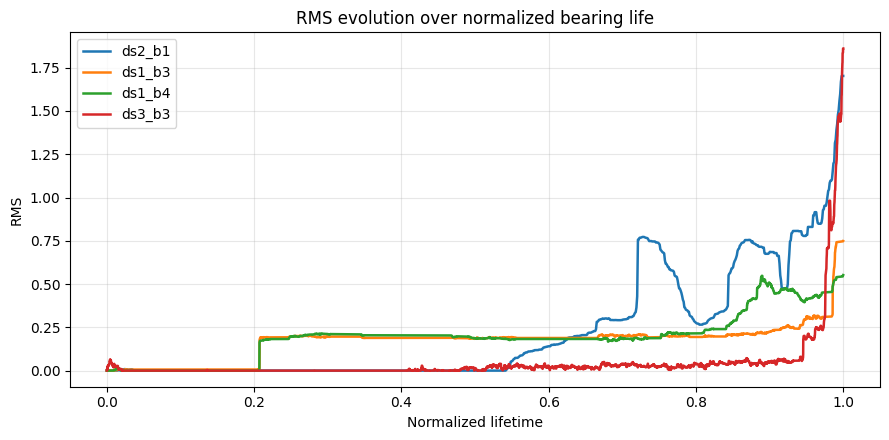

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_feature_evolution_kurtosis.png


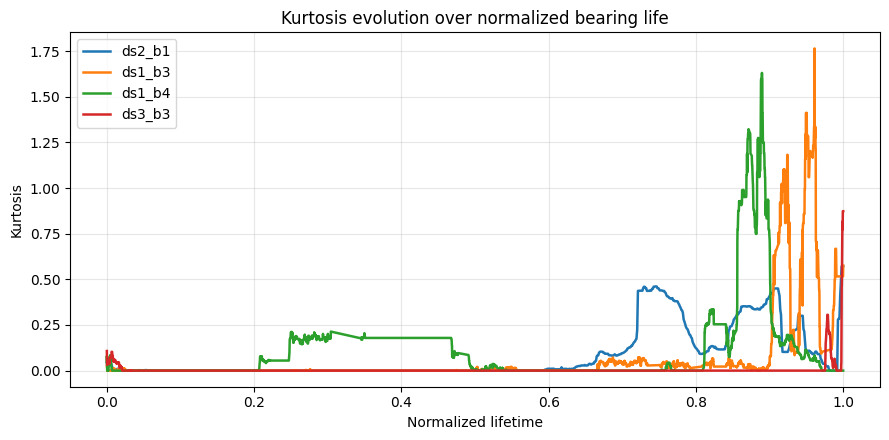

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_feature_evolution_crest_factor.png


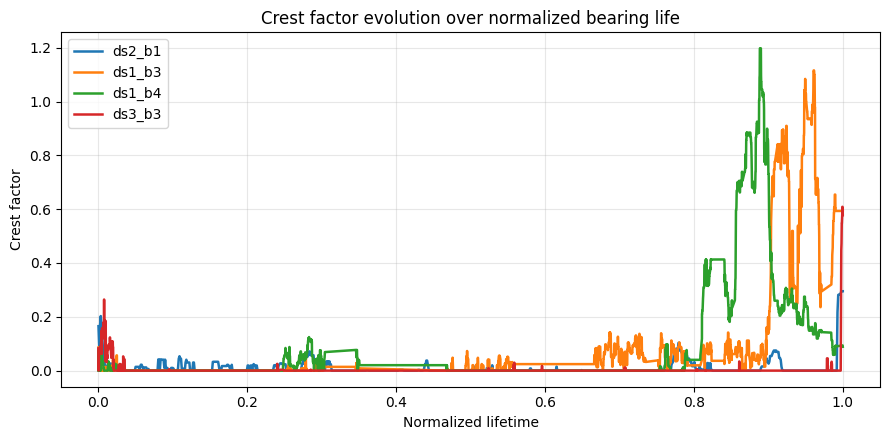

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_feature_evolution_e_kin.png


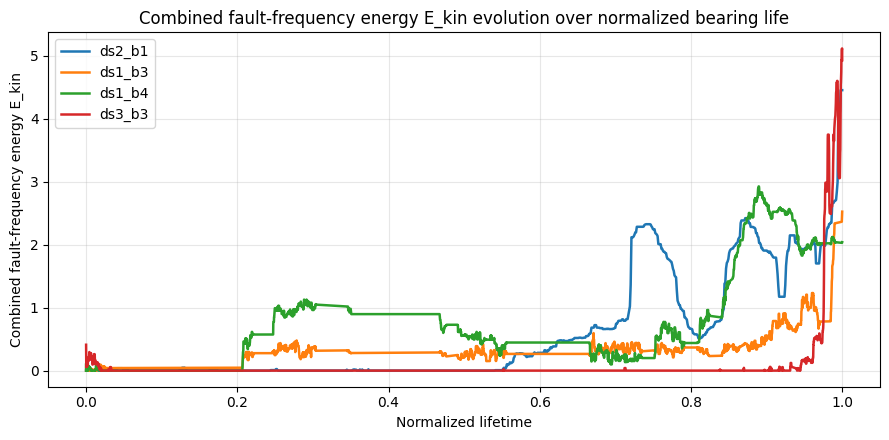

In [23]:
feature_plot_specs = [
    ('rms', 'RMS', 'fig_feature_evolution_rms.png'),
    ('kurtosis', 'Kurtosis', 'fig_feature_evolution_kurtosis.png'),
    ('crest_factor', 'Crest factor', 'fig_feature_evolution_crest_factor.png'),
    ('E_kin', 'Combined fault-frequency energy E_kin', 'fig_feature_evolution_e_kin.png'),
]

for feature_col, y_label, filename in feature_plot_specs:
    plt.figure(figsize=(9, 4.5))
    for run_id in [run_id for run_id, _, _ in TARGET_RUNS]:
        run = proc_df[proc_df['run_id'] == run_id].sort_values('elapsed_scaled')
        if run.empty:
            continue
        plt.plot(normalized_life_for_run(run), run[feature_col], label=run_id, linewidth=1.8)
    plt.title(f'{y_label} evolution over normalized bearing life')
    plt.xlabel('Normalized lifetime')
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

### Fault-Frequency Energy Evolution Graph

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_fault_energy_evolution.png


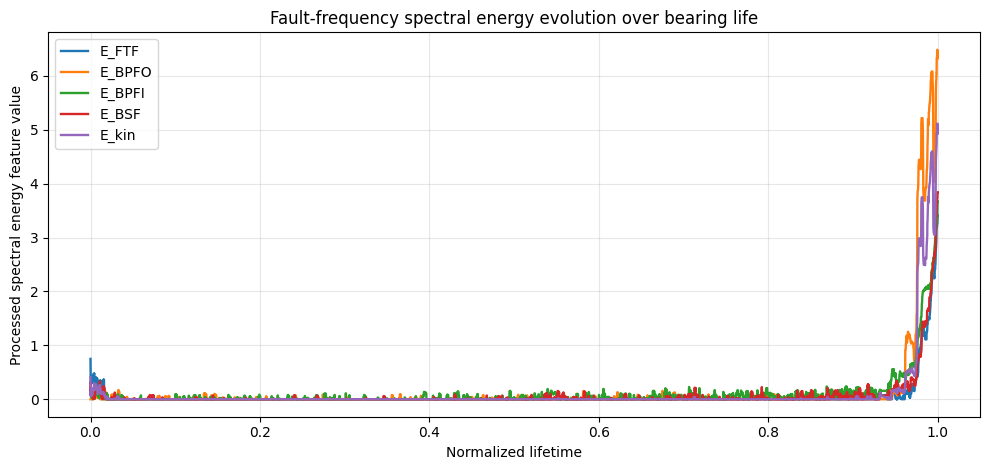

In [24]:
fault_energy_run_id = 'ds3_b3' if 'ds3_b3' in proc_df['run_id'].unique() else proc_df['run_id'].iloc[0]
fault_energy_run = proc_df[proc_df['run_id'] == fault_energy_run_id].sort_values('elapsed_scaled')

plt.figure(figsize=(10, 4.8))
for col in ['E_FTF', 'E_BPFO', 'E_BPFI', 'E_BSF', 'E_kin']:
    plt.plot(normalized_life_for_run(fault_energy_run), fault_energy_run[col], label=col, linewidth=1.7)
plt.title('Fault-frequency spectral energy evolution over bearing life')
plt.xlabel('Normalized lifetime')
plt.ylabel('Processed spectral energy feature value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
save_current_figure('fig_fault_energy_evolution.png')
plt.show()

### Envelope Spectrum with Fault-Frequency Markers

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_envelope_spectrum_fault_markers.png


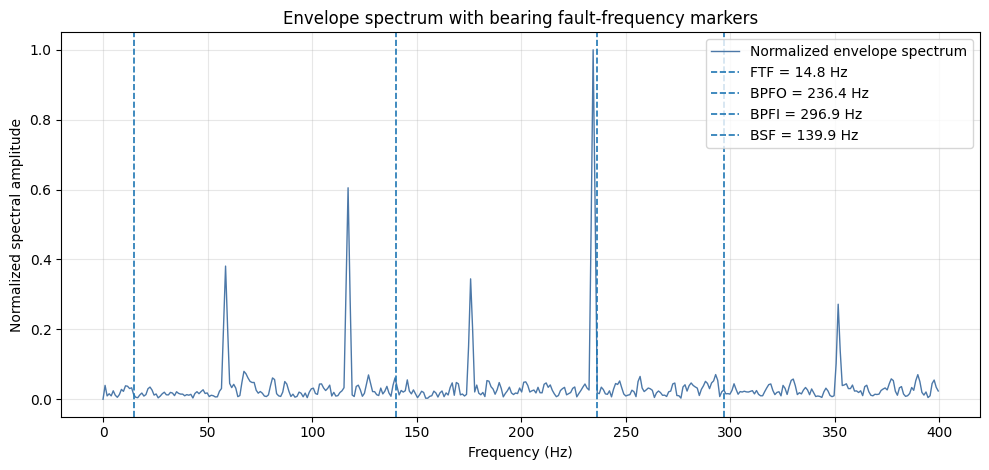

In [25]:
try:
    spectrum_signal, spectrum_file = get_raw_signal_for_run(raw_plot_run, 'late')
    freqs, spec = spectrum_features(spectrum_signal)
    spec_norm = spec / (spec.max() + 1e-12)
    max_freq = max(400, max(FAULT_FREQS.values()) * 1.25)
    mask = freqs <= max_freq

    plt.figure(figsize=(10, 4.8))
    plt.plot(freqs[mask], spec_norm[mask], linewidth=1.0, color='#4c78a8', label='Normalized envelope spectrum')
    for name, value in FAULT_FREQS.items():
        plt.axvline(value, linestyle='--', linewidth=1.2, label=f'{name} = {value:.1f} Hz')
    plt.title('Envelope spectrum with bearing fault-frequency markers')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normalized spectral amplitude')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_figure('fig_envelope_spectrum_fault_markers.png')
    plt.show()
except Exception as exc:
    display(Markdown(f'Envelope spectrum plot skipped because raw waveform/spectrum access failed safely: `{exc}`'))

### PCA-HI Ablation Table and Plot

PCA-HI is used only as an ablation/interpretability analysis. The main prediction target remains normalized RUL.

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/pca_hi_ablation_table.csv


,Bearing run,Monotonicity score,Correlation with damage,Interpretation
0,ds1_b3,0.765661,0.888651,Strongly degradation-consistent PCA-HI behavior
1,ds3_b3,0.863514,0.776637,Strongly degradation-consistent PCA-HI behavior


Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_pca_hi_ablation.png


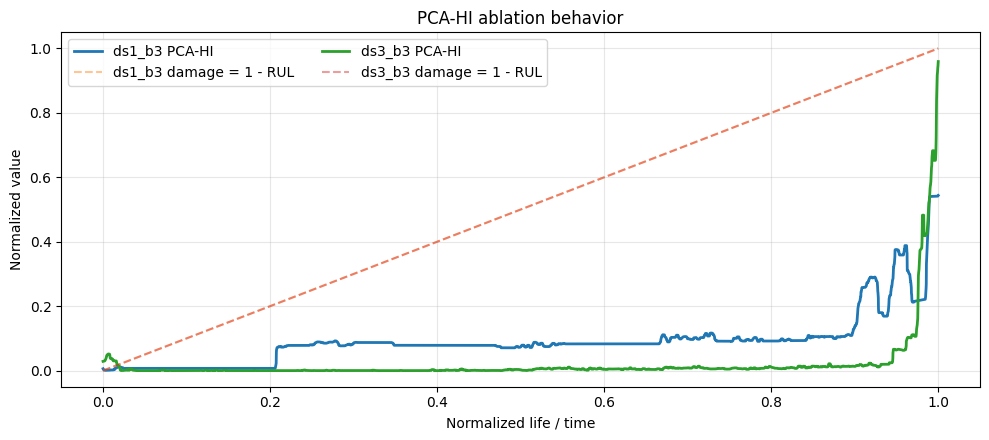

In [26]:
def interpret_pca_hi(row):
    corr = row['Correlation with damage']
    mono = row['Monotonicity score']
    if corr >= 0.7 and mono >= 0.7:
        return 'Strongly degradation-consistent PCA-HI behavior'
    if corr >= 0.4:
        return 'Moderately degradation-consistent PCA-HI behavior'
    return 'Weak or noisy degradation-consistency; interpret with caution'

pca_hi_ablation_table = pca_hi_summary.rename(columns={
    'Run': 'Bearing run',
    'Monotonic increase score': 'Monotonicity score',
    'Spearman corr(PCA-HI, damage)': 'Correlation with damage',
})[['Bearing run', 'Monotonicity score', 'Correlation with damage']]
pca_hi_ablation_table['Interpretation'] = pca_hi_ablation_table.apply(interpret_pca_hi, axis=1)
save_table(pca_hi_ablation_table, 'pca_hi_ablation_table.csv')

plt.figure(figsize=(10, 4.5))
for run_id in PCA_TEST_RUNS:
    run = pca_hi_df[pca_hi_df['run_id'] == run_id].sort_values('life_norm_for_plot')
    plt.plot(run['life_norm_for_plot'], run['pca_hi_smooth'], linewidth=2, label=f'{run_id} PCA-HI')
    plt.plot(run['life_norm_for_plot'], run['damage_norm'], linestyle='--', alpha=0.45, label=f'{run_id} damage = 1 - RUL')
plt.xlabel('Normalized life / time')
plt.ylabel('Normalized value')
plt.title('PCA-HI ablation behavior')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
save_current_figure('fig_pca_hi_ablation.png')
plt.show()

### Metric Comparison Bar Charts

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_metric_comparison_rmse.png


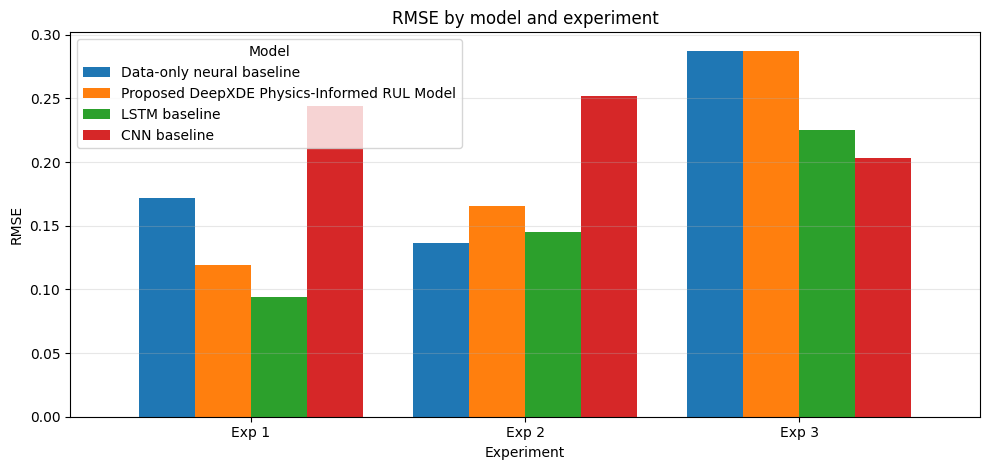

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_metric_comparison_mae.png


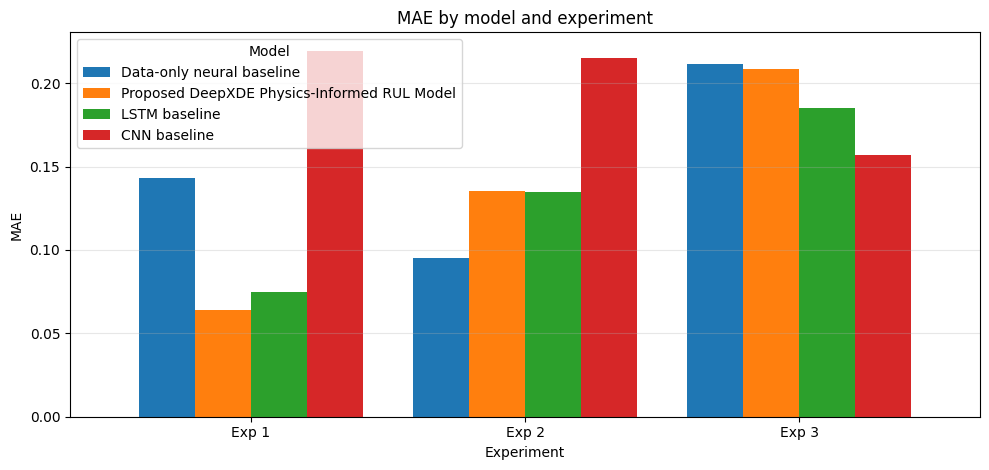

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_metric_comparison_r2.png


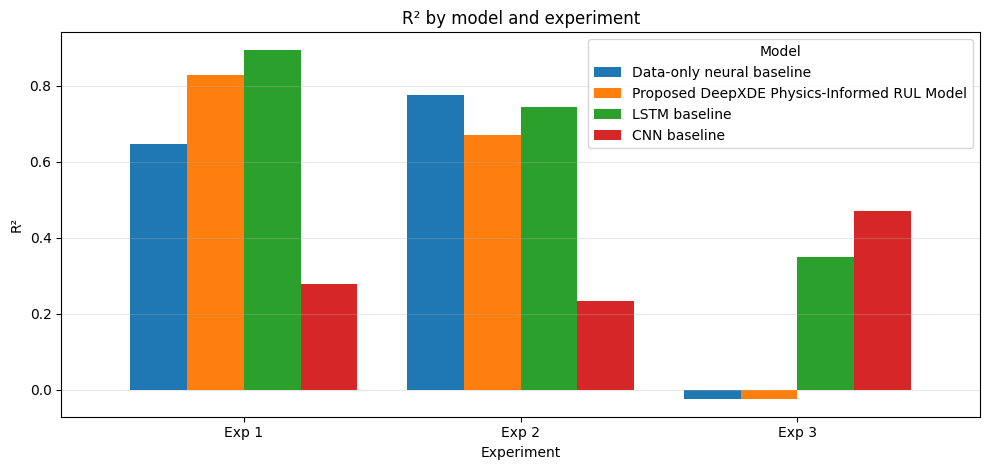

In [27]:
def plot_grouped_metric(metric_col, ylabel, title, filename):
    pivot = final_results.pivot(index='Experiment', columns='Model', values=metric_col)
    pivot = pivot[[model for model in MODEL_ORDER if model in pivot.columns]]
    ax = pivot.plot(kind='bar', figsize=(10, 4.8), width=0.82)
    ax.set_title(title)
    ax.set_xlabel('Experiment')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Model')
    plt.xticks(rotation=0)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

plot_grouped_metric('RMSE', 'RMSE', 'RMSE by model and experiment', 'fig_metric_comparison_rmse.png')
plot_grouped_metric('MAE', 'MAE', 'MAE by model and experiment', 'fig_metric_comparison_mae.png')
plot_grouped_metric('R²', 'R²', 'R² by model and experiment', 'fig_metric_comparison_r2.png')

### Average Model Performance Table and Plot

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/average_model_performance_table.csv


,Model,Average MAE,Average RMSE,Average R²,Overall interpretation
0,CNN baseline,0.197166,0.232998,0.327387,comparison baseline
1,Data-only neural baseline,0.149851,0.198595,0.465613,comparison baseline
2,LSTM baseline,0.131654,0.154713,0.662569,lowest average RMSE; lowest average MAE; highe...
3,Proposed DeepXDE Physics-Informed RUL Model,0.135806,0.190777,0.491781,proposed physics-informed model


Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_average_rmse_by_model.png


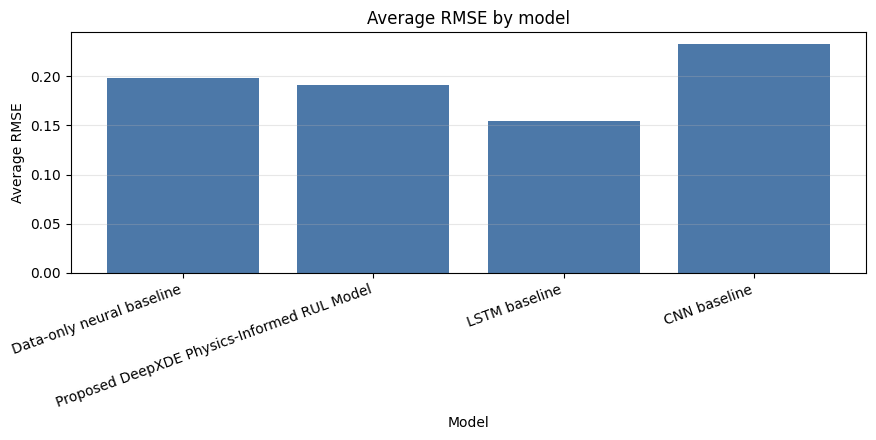

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_average_mae_by_model.png


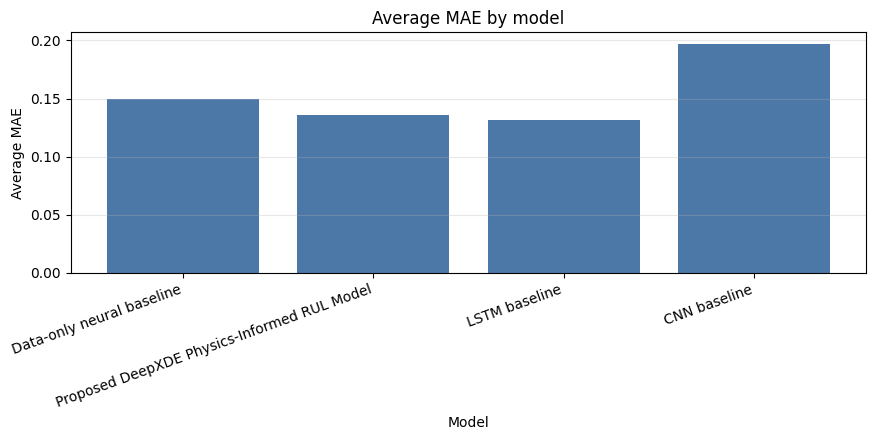

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_average_r2_by_model.png


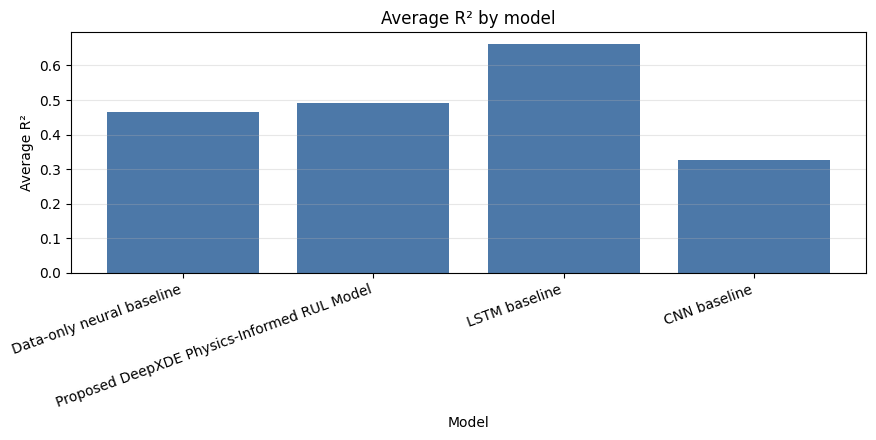

In [28]:
average_model_performance_table = (
    final_results
    .groupby('Model', as_index=False)
    .agg({'MAE': 'mean', 'RMSE': 'mean', 'R²': 'mean'})
    .rename(columns={'MAE': 'Average MAE', 'RMSE': 'Average RMSE', 'R²': 'Average R²'})
)

best_rmse_model = average_model_performance_table.loc[average_model_performance_table['Average RMSE'].idxmin(), 'Model']
best_mae_model = average_model_performance_table.loc[average_model_performance_table['Average MAE'].idxmin(), 'Model']
best_r2_model = average_model_performance_table.loc[average_model_performance_table[f'Average R²'].idxmax(), 'Model']

def average_interpretation(row):
    notes = []
    if row['Model'] == best_rmse_model:
        notes.append('lowest average RMSE')
    if row['Model'] == best_mae_model:
        notes.append('lowest average MAE')
    if row['Model'] == best_r2_model:
        notes.append('highest average R²')
    if row['Model'] == PROPOSED_MODEL_NAME:
        notes.append('proposed physics-informed model')
    if not notes:
        notes.append('comparison baseline')
    return '; '.join(notes)

average_model_performance_table['Overall interpretation'] = average_model_performance_table.apply(average_interpretation, axis=1)
save_table(average_model_performance_table, 'average_model_performance_table.csv')

for metric_col, ylabel, filename, title in [
    ('Average RMSE', 'Average RMSE', 'fig_average_rmse_by_model.png', 'Average RMSE by model'),
    ('Average MAE', 'Average MAE', 'fig_average_mae_by_model.png', 'Average MAE by model'),
    (f'Average R²', f'Average R²', 'fig_average_r2_by_model.png', f'Average R² by model'),
]:
    ordered = average_model_performance_table.set_index('Model').loc[[m for m in MODEL_ORDER if m in average_model_performance_table['Model'].values]]
    plt.figure(figsize=(9, 4.5))
    plt.bar(ordered.index, ordered[metric_col], color='#4c78a8')
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    plt.xticks(rotation=20, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

### Improvement Over Data-Only Baseline Table

In [29]:
improvement_rows = []
for experiment, group in final_results.groupby('Experiment'):
    data_only = group[group['Model'] == DATA_BASELINE_NAME]
    proposed = group[group['Model'] == PROPOSED_MODEL_NAME]
    if data_only.empty or proposed.empty:
        continue
    data_rmse = float(data_only['RMSE'].iloc[0])
    proposed_rmse = float(proposed['RMSE'].iloc[0])
    improvement = ((data_rmse - proposed_rmse) / (data_rmse + 1e-12)) * 100
    interpretation = (
        'PINN improves over data-only baseline in this experiment.'
        if improvement >= 0
        else 'PINN worse than data-only baseline in this experiment.'
    )
    improvement_rows.append({
        'Experiment': experiment,
        'Data-only baseline RMSE': data_rmse,
        'Proposed DeepXDE PINN RMSE': proposed_rmse,
        'RMSE improvement percentage': improvement,
        'Interpretation': interpretation,
    })

pinn_improvement_over_data_baseline = pd.DataFrame(improvement_rows)
save_table(pinn_improvement_over_data_baseline, 'pinn_improvement_over_data_baseline.csv')

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/pinn_improvement_over_data_baseline.csv


,Experiment,Data-only baseline RMSE,Proposed DeepXDE PINN RMSE,RMSE improvement percentage,Interpretation
0,Exp 1,0.171692,0.119313,30.507869,PINN improves over data-only baseline in this ...
1,Exp 2,0.136554,0.165566,-21.245742,PINN worse than data-only baseline in this exp...
2,Exp 3,0.287538,0.287452,0.029918,PINN improves over data-only baseline in this ...


PosixPath('/content/drive/MyDrive/thesis_outputs/figures_tables/pinn_improvement_over_data_baseline.csv')

### Model Ranking Table

Saved table: /content/drive/MyDrive/thesis_outputs/figures_tables/model_ranking_by_rmse.csv


,Experiment,Model,RMSE,Rank by RMSE
0,Exp 1,LSTM baseline,0.093678,1
1,Exp 1,Proposed DeepXDE Physics-Informed RUL Model,0.119313,2
2,Exp 1,Data-only neural baseline,0.171692,3
3,Exp 1,CNN baseline,0.243998,4
4,Exp 2,Data-only neural baseline,0.136554,1
5,Exp 2,LSTM baseline,0.145443,2
6,Exp 2,Proposed DeepXDE Physics-Informed RUL Model,0.165566,3
7,Exp 2,CNN baseline,0.251835,4
8,Exp 3,CNN baseline,0.203160,1
9,Exp 3,LSTM baseline,0.225019,2


Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_model_ranking_by_rmse.png


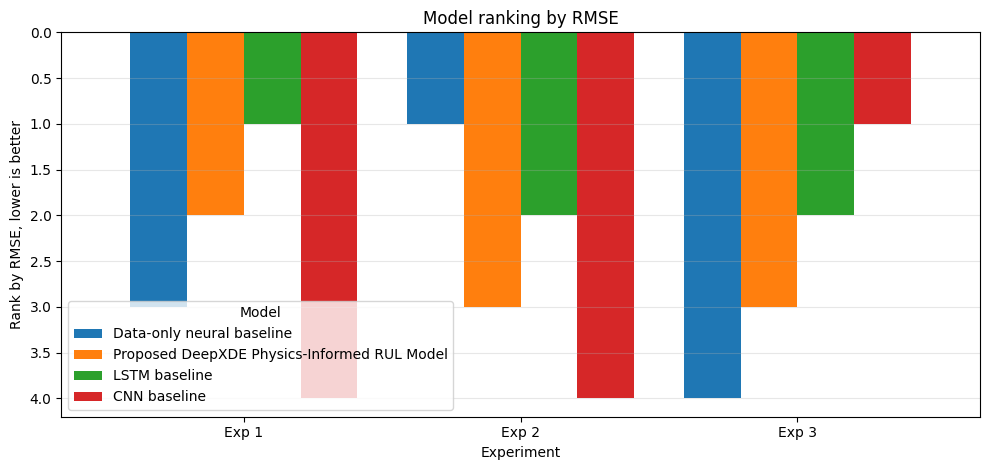

In [30]:
model_ranking_by_rmse = final_results[['Experiment', 'Model', 'RMSE']].copy()
model_ranking_by_rmse['Rank by RMSE'] = model_ranking_by_rmse.groupby('Experiment')['RMSE'].rank(method='dense', ascending=True).astype(int)
model_ranking_by_rmse = model_ranking_by_rmse.sort_values(['Experiment', 'Rank by RMSE']).reset_index(drop=True)
save_table(model_ranking_by_rmse, 'model_ranking_by_rmse.csv')

ranking_pivot = model_ranking_by_rmse.pivot(index='Experiment', columns='Model', values='Rank by RMSE')
ranking_pivot = ranking_pivot[[model for model in MODEL_ORDER if model in ranking_pivot.columns]]
ax = ranking_pivot.plot(kind='bar', figsize=(10, 4.8), width=0.82)
ax.set_title('Model ranking by RMSE')
ax.set_xlabel('Experiment')
ax.set_ylabel('Rank by RMSE, lower is better')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
save_current_figure('fig_model_ranking_by_rmse.png')
plt.show()

### True vs Predicted RUL Scatter Plots

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_true_vs_predicted_exp1.png


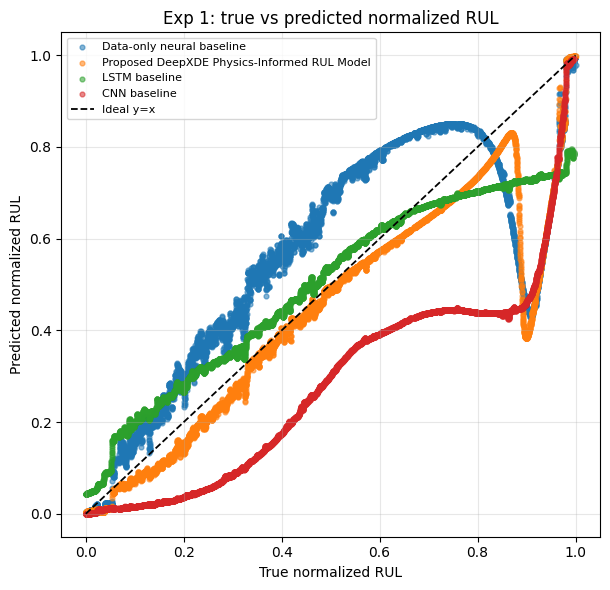

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_true_vs_predicted_exp2.png


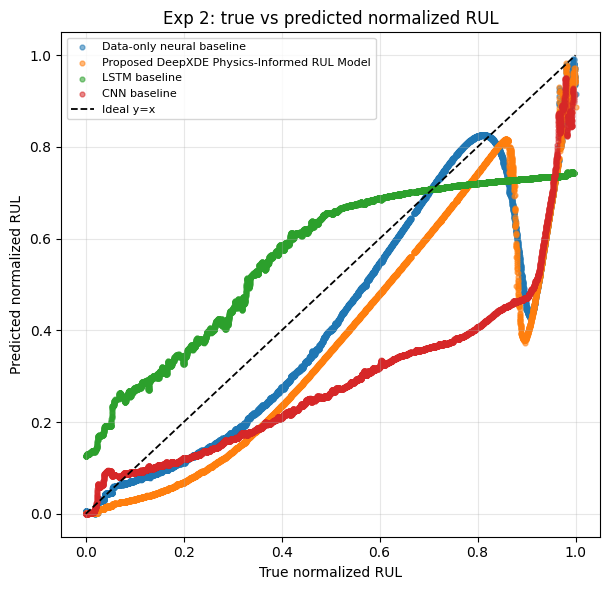

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_true_vs_predicted_exp3.png


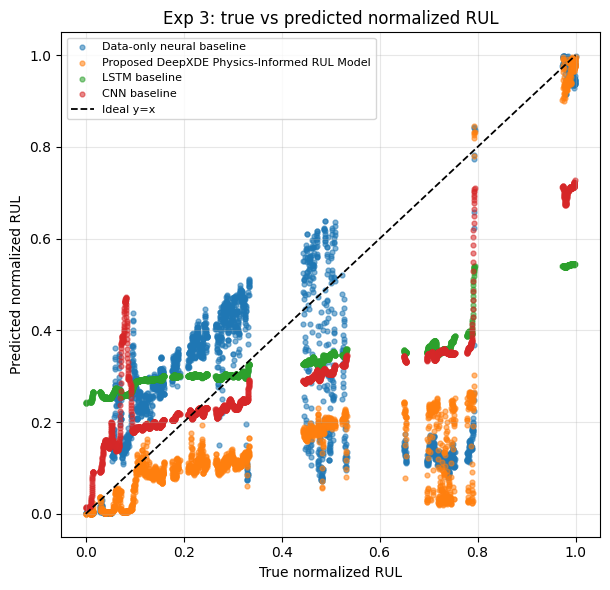

In [31]:
def aligned_true_values(exp_name, model_name):
    preds = prediction_store[exp_name]
    x_true = preds['x_true']
    true_rul = preds['true']
    x_pred = preds['x_by_model'][model_name]
    return np.interp(x_pred, x_true, true_rul)


SCATTER_FIGURE_FILENAMES = {
    'Exp 1': 'fig_true_vs_predicted_exp1.png',
    'Exp 2': 'fig_true_vs_predicted_exp2.png',
    'Exp 3': 'fig_true_vs_predicted_exp3.png',
}

for spec in EXPERIMENTS:
    exp_name = spec['name']
    preds = prediction_store[exp_name]
    plt.figure(figsize=(6.2, 6.0))
    for model_name in MODEL_ORDER:
        if model_name not in preds:
            continue
        pred = preds[model_name]
        true_aligned = aligned_true_values(exp_name, model_name)
        if len(true_aligned) != len(pred):
            raise ValueError(f'Misaligned scatter data for {exp_name} {model_name}')
        plt.scatter(true_aligned, pred, s=12, alpha=0.55, label=model_name)
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.3, label='Ideal y=x')
    plt.title(f'{exp_name}: true vs predicted normalized RUL')
    plt.xlabel('True normalized RUL')
    plt.ylabel('Predicted normalized RUL')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    save_current_figure(SCATTER_FIGURE_FILENAMES[exp_name])
    plt.show()

### Residual Error Over Lifetime

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_residuals_exp1.png


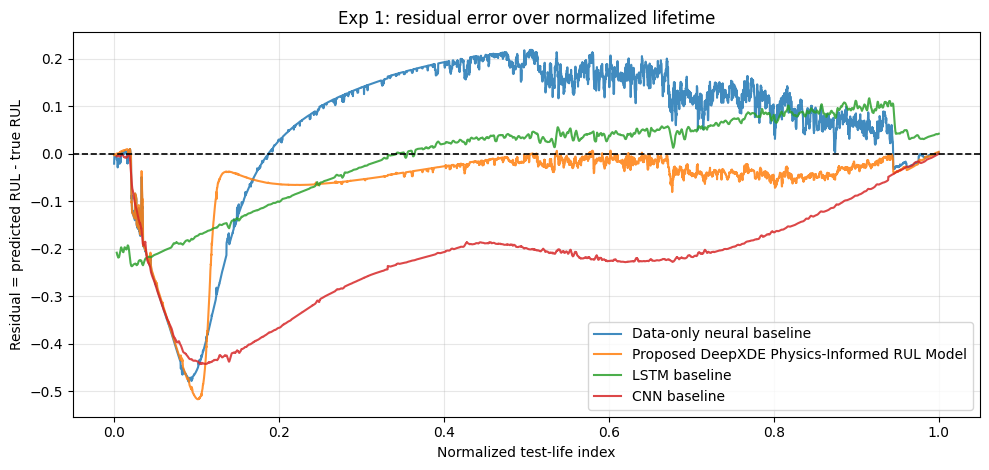

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_residuals_exp2.png


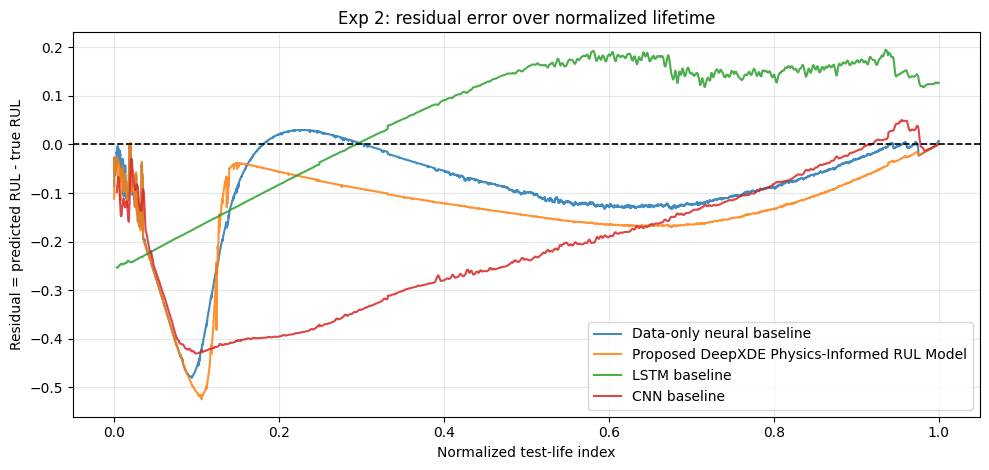

Saved figure: /content/drive/MyDrive/thesis_outputs/figures_tables/fig_residuals_exp3.png


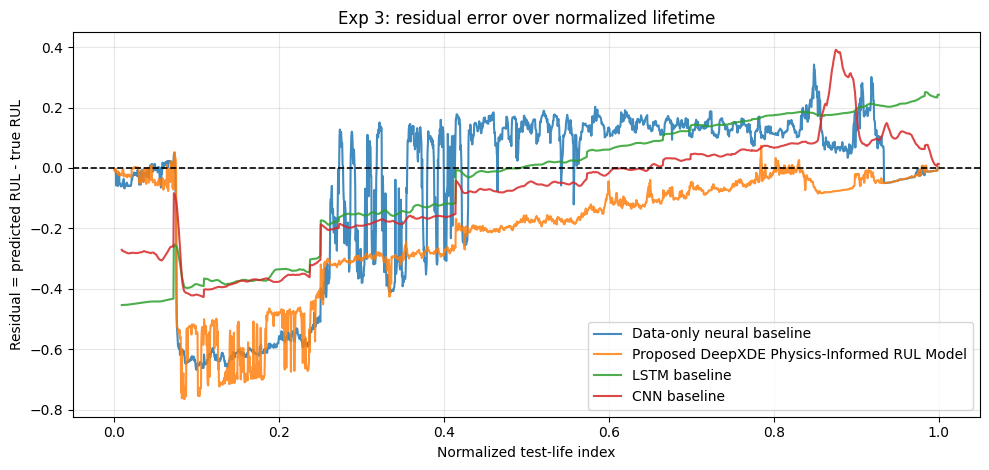

In [32]:
RESIDUAL_FIGURE_FILENAMES = {
    'Exp 1': 'fig_residuals_exp1.png',
    'Exp 2': 'fig_residuals_exp2.png',
    'Exp 3': 'fig_residuals_exp3.png',
}

for spec in EXPERIMENTS:
    exp_name = spec['name']
    preds = prediction_store[exp_name]
    plt.figure(figsize=(10, 4.8))
    for model_name in MODEL_ORDER:
        if model_name not in preds:
            continue
        pred = preds[model_name]
        x_pred = preds['x_by_model'][model_name]
        true_aligned = aligned_true_values(exp_name, model_name)
        residual = pred - true_aligned
        plt.plot(x_pred, residual, linewidth=1.5, alpha=0.85, label=model_name)
    plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
    plt.title(f'{exp_name}: residual error over normalized lifetime')
    plt.xlabel('Normalized test-life index')
    plt.ylabel('Residual = predicted RUL - true RUL')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_figure(RESIDUAL_FIGURE_FILENAMES[exp_name])
    plt.show()

## Final Thesis Tables and Figures Generated

In [33]:
print('All additional thesis CSV tables and PNG figures were saved to:')
print(THESIS_OUTPUT_DIR)

for table_name, table_df in [
    ('Dataset summary table', dataset_summary_table),
    ('Experiment split table', experiment_split_table),
    ('Model summary table', model_summary_table),
    ('Final results table', final_results),
    ('Average model performance table', average_model_performance_table),
    ('Improvement over data-only baseline table', pinn_improvement_over_data_baseline),
    ('Model ranking table', model_ranking_by_rmse),
]:
    display(Markdown(f'### {table_name}'))
    display(table_df)

All additional thesis CSV tables and PNG figures were saved to:
/content/drive/MyDrive/thesis_outputs/figures_tables


### Dataset summary table

,Run ID,IMS dataset,Bearing number,Failure type if available,Number of samples,Used in experiments,Notes
0,ds2_b1,2nd_test,1,Not specified in cleaned notebook,984,Exp 1 Train; Exp 2 Train; Exp 3 Train,Run-to-failure IMS bearing run used in cross-b...
1,ds1_b3,1st_test,3,Not specified in cleaned notebook,2156,Exp 1 Train; Exp 2 Validation; Exp 3 Test,Run-to-failure IMS bearing run used in cross-b...
2,ds1_b4,1st_test,4,Not specified in cleaned notebook,2156,Exp 1 Validation; Exp 2 Train; Exp 3 Validation,Run-to-failure IMS bearing run used in cross-b...
3,ds3_b3,3rd_test,3,Not specified in cleaned notebook,6324,Exp 1 Test; Exp 2 Test; Exp 3 Train,Run-to-failure IMS bearing run used in cross-b...


### Experiment split table

,Experiment,Train runs,Validation run,Test run,Purpose
0,Exp 1,ds2_b1 + ds1_b3,ds1_b4,ds3_b3,Cross-dataset/cross-bearing transfer with ds3_...
1,Exp 2,ds2_b1 + ds1_b4,ds1_b3,ds3_b3,Alternative training-bearing combination with ...
2,Exp 3,ds2_b1 + ds3_b3,ds1_b4,ds1_b3,Cross-dataset transfer to ds1_b3 with balanced...


...

,Model,Average MAE,Average RMSE,Average R²,Overall interpretation
0,CNN baseline,0.197166,0.232998,0.327387,comparison baseline
1,Data-only neural baseline,0.149851,0.198595,0.465613,comparison baseline
2,LSTM baseline,0.131654,0.154713,0.662569,lowest average RMSE; lowest average MAE; highe...
3,Proposed DeepXDE Physics-Informed RUL Model,0.135806,0.190777,0.491781,proposed physics-informed model


### Improvement over data-only baseline table

,Experiment,Data-only baseline RMSE,Proposed DeepXDE PINN RMSE,RMSE improvement percentage,Interpretation
0,Exp 1,0.171692,0.119313,30.507869,PINN improves over data-only baseline in this ...
1,Exp 2,0.136554,0.165566,-21.245742,PINN worse than data-only baseline in this exp...
2,Exp 3,0.287538,0.287452,0.029918,PINN improves over data-only baseline in this ...


### Model ranking table

,Experiment,Model,RMSE,Rank by RMSE
0,Exp 1,LSTM baseline,0.093678,1
1,Exp 1,Proposed DeepXDE Physics-Informed RUL Model,0.119313,2
2,Exp 1,Data-only neural baseline,0.171692,3
3,Exp 1,CNN baseline,0.243998,4
4,Exp 2,Data-only neural baseline,0.136554,1
5,Exp 2,LSTM baseline,0.145443,2
6,Exp 2,Proposed DeepXDE Physics-Informed RUL Model,0.165566,3
7,Exp 2,CNN baseline,0.251835,4
8,Exp 3,CNN baseline,0.203160,1
9,Exp 3,LSTM baseline,0.225019,2
